## CSC3105 - Data Analytics
### Group 18 Members:
1. Chen Jieyang [ 2400648 | 3070593C ]
2. Kwok Chang Feng Zenden [ 2402538 | 3070693K ]
3. Lim Wei Zhe Bryan [ 2401331 | 3070646L ]
4. Tan Bao Quan [ 2402547 | 3070694T ]
5. Tang Wee Jer [ 2403409 | 3070571T ]

---

### Project Goal:
* Classify each signal path as LOS (0) or NLOS (1)
* Estimate the distance for the two shortest and dominant signal paths

### Project Stages:
0. [Installation & Importing](#INSTALLATION-&-IMPORTING)
1. [Data Exploration](#DATA-EXPLORATION)
3. [Data Preprocessing](#DATA-PREPROCESSING)
4. [Classification Model](#CLASSIFICATION-MODEL)
5. [Regression Model](#REGRESSION-MODEL)
6. [Integrated 3 Stage Test](#INTEGRATED-3-STAGE-TEST)

## INSTALLATION & IMPORTING
---
This section contains all the necessary libraries installation and imports required to run the rest of the notebook.

In [63]:
# Install libraries
!pip install scikit-learn xgboost matplotlib seaborn imbalanced-learn pandas numpy scipy -q

In [64]:
# Standard Library
import glob
import os
import time

# Data Handling
import pandas as pd
import numpy as np

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Preprocessing & Dimensionality Reduction 
from scipy.stats import kurtosis as scipy_kurtosis
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, 
    cross_validate, 
    cross_val_score,
    cross_val_predict
)

# ML models
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingRegressor, 
    RandomForestRegressor
)

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("All imports successful")

All imports successful


# DATA EXPLORATION
---  
We begin by loading and understanding the dataset before any preprocessing or modelling. This stage covers dataset structure, data quality, class balance, and feature behaviour across classes.

### LOAD DATASET  
**Purpose**  
All 7 csv files were loaded, from the UWB dataset, and merged for ease of transformation and analysis. An initial inspection of the shape, column names, and first few rows confirms the data loaded correctly.  

<u>**Results**</u>  
The merged dataset contains **42000 samples** and **1031 columns**:
- 15 signal features
- 1016 CIR sample columns
- 1 target label - `NLOS`

In [65]:
# Import all 7 files
files = sorted(glob.glob(os.path.join('.', 'data', 'raw', 'uwb_dataset_part*.csv')))
assert len(files) == 7, f"Expected 7 files, found {len(files)}"
print("Files found: ", len(files))

# Merge all files found
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Verify file import is successful
print("Database shape: ", df.shape)
df.head()

Files found:  7
Database shape:  (42000, 1031)


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


### DATA INTEGRITY CHECK
To ensure the dataset is clean, consistent, and hence suitable for modelling, we check for missing values, duplicate, rows and ensure the target label contains only the expected binary values (`0` = LOS, `1` = NLOS). Descriptive statistics are also reviewed to identify abnormalities in feature value ranges or scales.

<u>**Results**</u>  
The dataset contains **no missing values** and **no duplicate rows**, confirming it is clean and ready for preprocessing. The `NLOS` label holds only `[0.0, 1.0]` as expected.  
  
Descriptive statistics reveal significant scale differences between features (e.g. `FP_AMP1` ranges up to ~20,000 while `STDEV_NOISE` ranges ~324), indicating that **feature scaling will be necessary** before model training.

In [66]:
# NULL value check
print("Missing values: ", df.isnull().sum().sum())

# Duplicate rows check
print("Duplicate rows: ", df.duplicated().sum())

# Confirm class label column only has 0 or 1 values
print("\nLabel column (NLOS) unique vaues: ", df['NLOS'].unique())

# Check column names
cols = df.columns[:20].tolist()
print("Column names (first 20):")
for i in range(0, len(cols), 4):          # 4 per row
    row = cols[i:i+4]
    print("  " + "  |  ".join(f"{c:<25}" for c in row))

# Descriptive statistics
df.describe()

Missing values:  0
Duplicate rows:  0

Label column (NLOS) unique vaues:  [0. 1.]
Column names (first 20):
  NLOS                       |  RANGE                      |  FP_IDX                     |  FP_AMP1                  
  FP_AMP2                    |  FP_AMP3                    |  STDEV_NOISE                |  CIR_PWR                  
  MAX_NOISE                  |  RXPACC                     |  CH                         |  FRAME_LEN                
  PREAM_LEN                  |  BITRATE                    |  PRFR                       |  CIR0                     
  CIR1                       |  CIR2                       |  CIR3                       |  CIR4                     


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.00000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.500000,3.831519,745.654167,8127.521905,11425.259524,9738.106048,72.284571,9789.690214,1316.096524,616.27250,...,257.455357,267.230833,249.123929,225.917143,239.445476,240.034286,254.388095,243.190643,253.173595,90.203429
std,0.500006,2.355976,4.505024,5393.330697,6235.434769,5352.311549,29.318995,4912.556005,582.434989,306.78537,...,148.613220,155.703171,132.054825,113.041790,131.519415,133.820366,177.274537,135.598470,145.780909,145.839730
min,0.000000,0.000000,707.000000,7.000000,63.000000,187.000000,28.000000,0.000000,310.000000,128.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000
25%,0.000000,1.810000,744.000000,3573.750000,5322.750000,4723.000000,56.000000,6727.000000,961.000000,318.00000,...,161.000000,161.000000,161.000000,150.000000,154.000000,154.000000,155.000000,154.000000,158.000000,0.000000
50%,0.500000,3.480000,746.000000,7140.000000,12318.000000,10262.000000,68.000000,9950.500000,1134.000000,513.00000,...,233.000000,243.000000,233.000000,217.000000,225.000000,227.000000,229.000000,223.000000,230.000000,0.000000
75%,1.000000,5.420000,748.000000,12273.000000,17310.000000,14256.000000,80.000000,12443.000000,1488.000000,1024.00000,...,313.000000,338.000000,304.000000,275.000000,288.000000,292.000000,297.000000,295.000000,308.000000,256.000000
max,1.000000,28.020000,848.000000,20572.000000,20624.000000,20577.000000,324.000000,37208.000000,5169.000000,1056.00000,...,1593.000000,1497.000000,1172.000000,1169.000000,1315.000000,1595.000000,2153.000000,1428.000000,1709.000000,1280.000000


### CLASS DISTRIBUTION  
We examined the proportion of LOS and NLOS samples to determine whether the dataset is balanced. An imbalanced distribution can bias a classifier towards the majority class and may require tuning of class weights.

<u>**Results**</u>  
The dataset is **perfectly balanced** with 21,000 LOS and NLOS samples each (50/50). A standard accuracy metrics will therefore be used for evaluation.

LOS samples: 21000
NLOS samples: 21000
Balance ratio: 1.00 



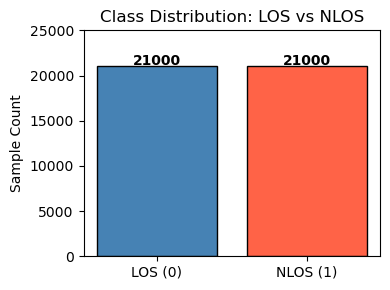

In [67]:
class_counts = df['NLOS'].value_counts().sort_index()

print(f'LOS samples: {class_counts[0.0]}')
print(f'NLOS samples: {class_counts[1.0]}')
print(f'Balance ratio: {class_counts[0.0]/class_counts[1.0]:.2f} \n')

# Bar Graph
fig, ax = plt.subplots(figsize=(4, 3))

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 200, str(v), ha='center', fontweight='bold')
ax.set_title('Class Distribution: LOS vs NLOS')
ax.bar(['LOS (0)', 'NLOS (1)'], class_counts.values, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_ylabel('Sample Count')
ax.set_ylim(0, 25000)
plt.tight_layout()
plt.show()

### CLASS SEPARATION 
We examine whether LOS and NLOS sampels are linearly separable by plotting key feature pairs. We selected feature pairs that are physically coupled (features simultaneously affected by the same NLOS obstruction event), based on the signal characteristics described. Significant class overlap would confirm that a non-linear classifier is needed, as a simple linear decision boundary would be insufficient to distinguish the two classes.  

<u>**Results**</u>  
The scatteprlot revelas that even when combining the physically meaningful features, the LOS and NLOS classes show significant overlap with no clear linear boundar; confirming that a **non-linear classifier** should be used.

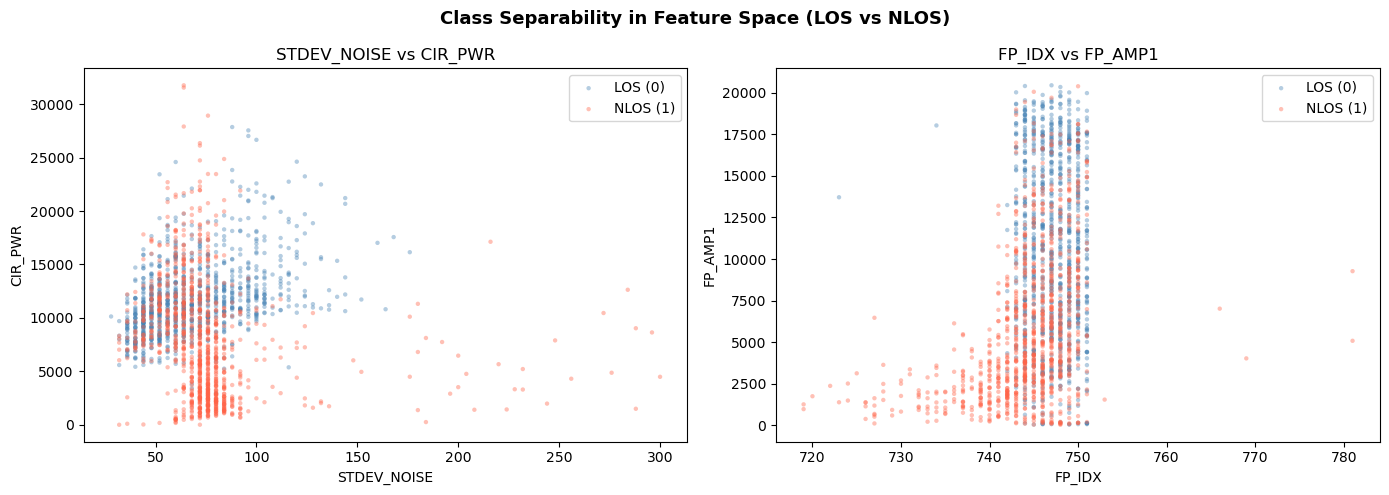

In [68]:
key_pairs = [
    ('STDEV_NOISE', 'CIR_PWR'),
    ('FP_IDX', 'FP_AMP1'),
]

# Scatterplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {0.0: 'steelblue', 1.0: 'tomato'}
labels = {0.0: 'LOS (0)', 1.0: 'NLOS (1)'}

for ax, (fx, fy) in zip(axes, key_pairs):
    for cls in [0.0, 1.0]:
        mask = df['NLOS'] == cls
        sample = df[mask].sample(1000, random_state=42)  # subsample to avoid overplotting
        ax.scatter(sample[fx], sample[fy], s=10, alpha=0.4,
                   color=colors[cls], label=labels[cls], edgecolors='none')
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}')
    ax.legend()

plt.suptitle('Class Separability in Feature Space (LOS vs NLOS)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### FEATURE DISTRIBUTION (BY CLASS)  
We visualize the probability density distributions of the 6 key signal features (determined through research) separately for LOS/NLOS classes. Features with clear separation between the two distributions indicate strong predictive power for classification.

<u>**Results**</u>  
The histograms reveals:  
* `RANGE` shows the least separation with both classes heavily overlapping across all distances.
  
* `MAX_NOISE`, `STDEV_NOISE`, and `CIR_PWR` shows partial separation in distribution shape, though with heavy overlap in some areas.
  
* `RXPACC` shows the clearest class separation, making it the most discriminative feature.
  
* `FP_AMP1` reveals that LOS signals carry significantly higher first-path amplitude, consistent with unobstructed signal propagation, while NLOS amplitudes are right-skewed and attenuated, indicating a weaker or blocked direct path.
  
Since no single feature achieves clean separation, a **multi-feature non-linear model** is needed to learn complex combined decision boundaries.  

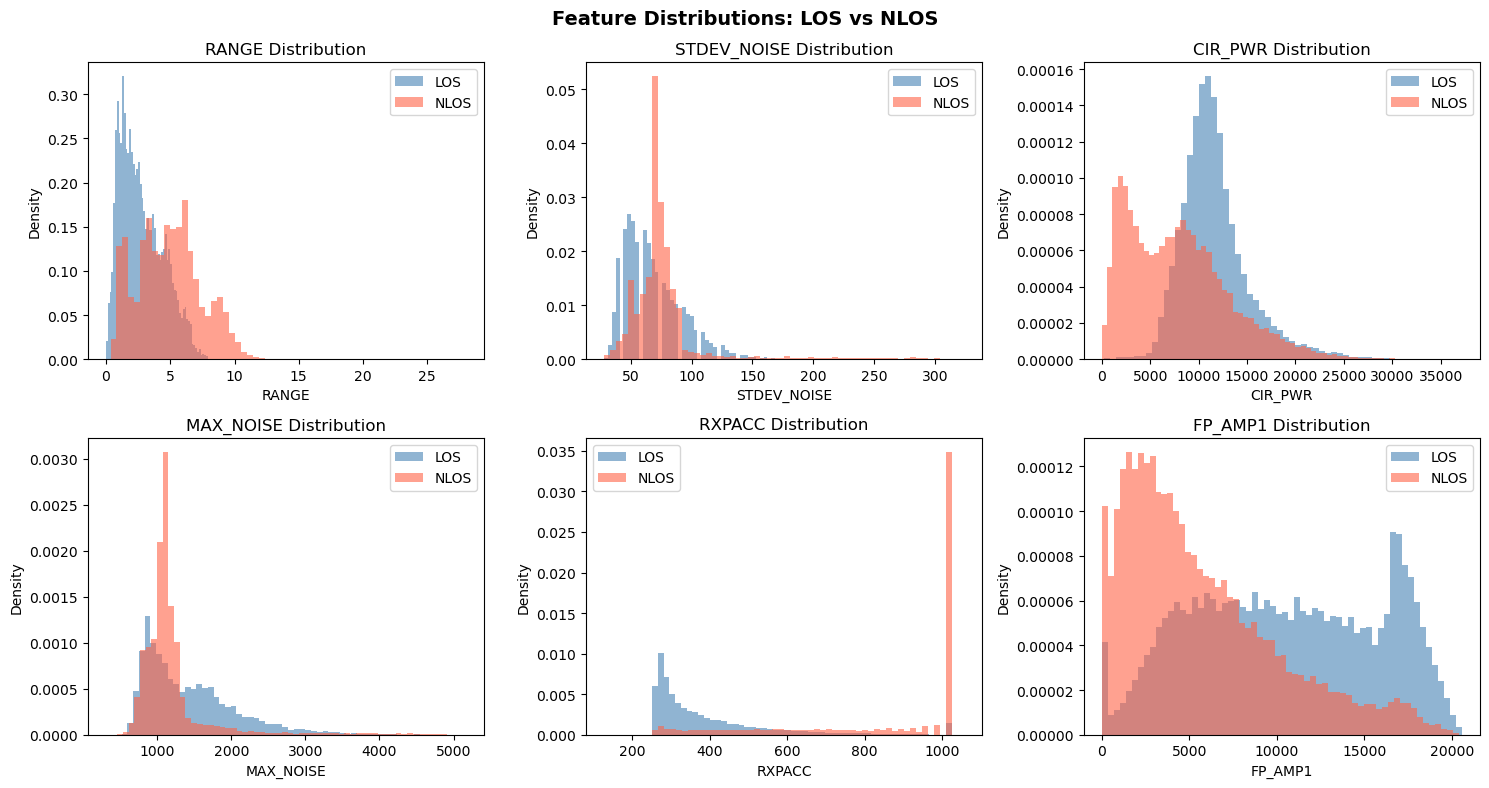

In [69]:
key_features = ['RANGE', 'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC', 'FP_AMP1']

# Histogram
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    los_vals  = df.loc[df['NLOS'] == 0.0, feat]
    nlos_vals = df.loc[df['NLOS'] == 1.0, feat]
    axes[i].hist(los_vals,  bins=60, alpha=0.6, color='steelblue', label='LOS',  density=True)
    axes[i].hist(nlos_vals, bins=60, alpha=0.6, color='tomato',    label='NLOS', density=True)
    axes[i].set_title(f'{feat} Distribution')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions: LOS vs NLOS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## DATA PREPROCESSING  
---
We prepared the raw dataset for model training through feature separation, CIR-specific processing, dimensionality reduction, feature engineering, and train/test splitting  

### FEATURE & LABEL SEPARATION
We split the dataset into three groups:
* Target label (`NLOS`)
* 14 signal features
* 1,016 CIR columns

<div style="background:#f0f0f0; padding:10px; border-radius:5px;">
<strong>Note:</strong> CIR is separated because it requires its own preprocessing pipeline before it can be recombined into the signal features.
</div>

<u>**Results**</u>  
The dataset is cleanly separated into labels, signal features, and CIR columns. Assertions confirm no label leakage and that all row counts match.

In [70]:
# Separate summary features
summary_cols = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
    'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR'
]

# Separate CIR waveform features
cir_cols = [col for col in df.columns if col.startswith("CIR")]

# Labelling of 3 groups
y = df["NLOS"]
X_summary = df[summary_cols]
X_cir = df[cir_cols]

# Error-prevention checks
# Confirm RANGE not accidentally dropped
assert 'RANGE' in summary_cols, "RANGE missing from summary cols!"
# Confirm NLOS is not included as a signal feature
assert 'NLOS'  not in summary_cols, "NLOS label leaked into features!"
# Confirm no non-CIR columns included into cir_cols
assert all(c.startswith('CIR') for c in cir_cols), "Non-CIR col in cir_cols!"
# Confirm all three gorups have same number of rows
assert X_summary.shape[0] == X_cir.shape[0] == len(y), "Row count mismatch!"

print(f"Summary cols : {len(summary_cols)}")
print(f"CIR cols     : {len(cir_cols)}")
print(f"Labels shape : {y.shape}")

Summary cols : 14
CIR cols     : 1017
Labels shape : (42000,)


### CIR ALIGNMENT & WINDOWING
For each CIR waveform, only the region around the first detected path (`FP_IDX`) carries useful signal information, the rest is mostly noise. Therefore, we centre each CIR around its `FP_IDX` and extract a fixed-width window to focus the model on the relevant signal region.
  
  For each sample:
1. Read the FP_IDX (first-path index) from X_summary
2. Shift the CIR so the peak is centred at position window//2
3. Keep only a window of `window` samples around the peak
 
  Returns array of shape (n_samples, window)

<u>**Results**</u>  
**Before alignment - full view (top left):**  
The raw CIR spans 1,016 samples but is almost entirely flat noise, with a small peak appearing around index ~745. The vast majority of samples carry no useful signal.

**Before alignment — zoomed view (top right):**  
Zooming into the peak region shows that LOS (blue) has a noticeably taller, sharper peak than NLOS (red), but both peaks sit at slightly different positions per sample, making direct comparison unreliable without alignment.

**After alignment — averaged view (bottom left):**  
Once all waveforms are centred such that the peak lands at index 50, the class difference becomes clearer. LOS reaches a higher peak (\~14,000) and drops off more steeply, while NLOS is shorter (\~10,000) and broader; reflecting signal attenuation caused by physical obstacles.

**After alignment — individual traces (bottom right):**  
Looking at 10 individual samples per class confirms the pattern is consistent, not just an averaging effect. LOS traces cluster tightly around a sharp peak, while NLOS traces show more spread and variation after the peak, indicating multipath scattering.

**Conclusion**  
The alignment successfully removes positional noise and focuses each waveform on
the 100 samples that matter most (the signal around the first detected path).

In [71]:
# CIR PEAK ALIGNMENT + WINDOWING
WINDOW = 100        # keep 100 samples around the peak (50 before, 50 after)
fp_col_pos = list(X_summary.columns).index('FP_IDX')     # column index of FP_IDX in X_summary (0=RANGE, 1=FP_IDX)

def align_and_window_cir(X_cir_raw, X_summary_raw, window=WINDOW, fp_col=fp_col_pos):
    half = window // 2
    n, n_cir = X_cir_raw.shape
    aligned = np.zeros((n, window), dtype=np.float32)

    for i in range(n):
        peak_idx = int(X_summary_raw[i, fp_col_pos])   # FP_IDX tells us where the peak is

        # Compute source slice bounds (clamp to valid range)
        src_start = max(0, peak_idx - half)
        src_end   = min(n_cir, peak_idx + half)

        # Compute destination slice bounds
        dst_start = half - (peak_idx - src_start)
        dst_end   = dst_start + (src_end - src_start)

        aligned[i, dst_start:dst_end] = X_cir_raw[i, src_start:src_end]

    return aligned

# Apply alignment BEFORE splitting
X_cir_aligned = align_and_window_cir(X_cir.values, X_summary.values, window=WINDOW)
print(f"Aligned CIR shape: {X_cir_aligned.shape}")

Aligned CIR shape: (42000, 100)


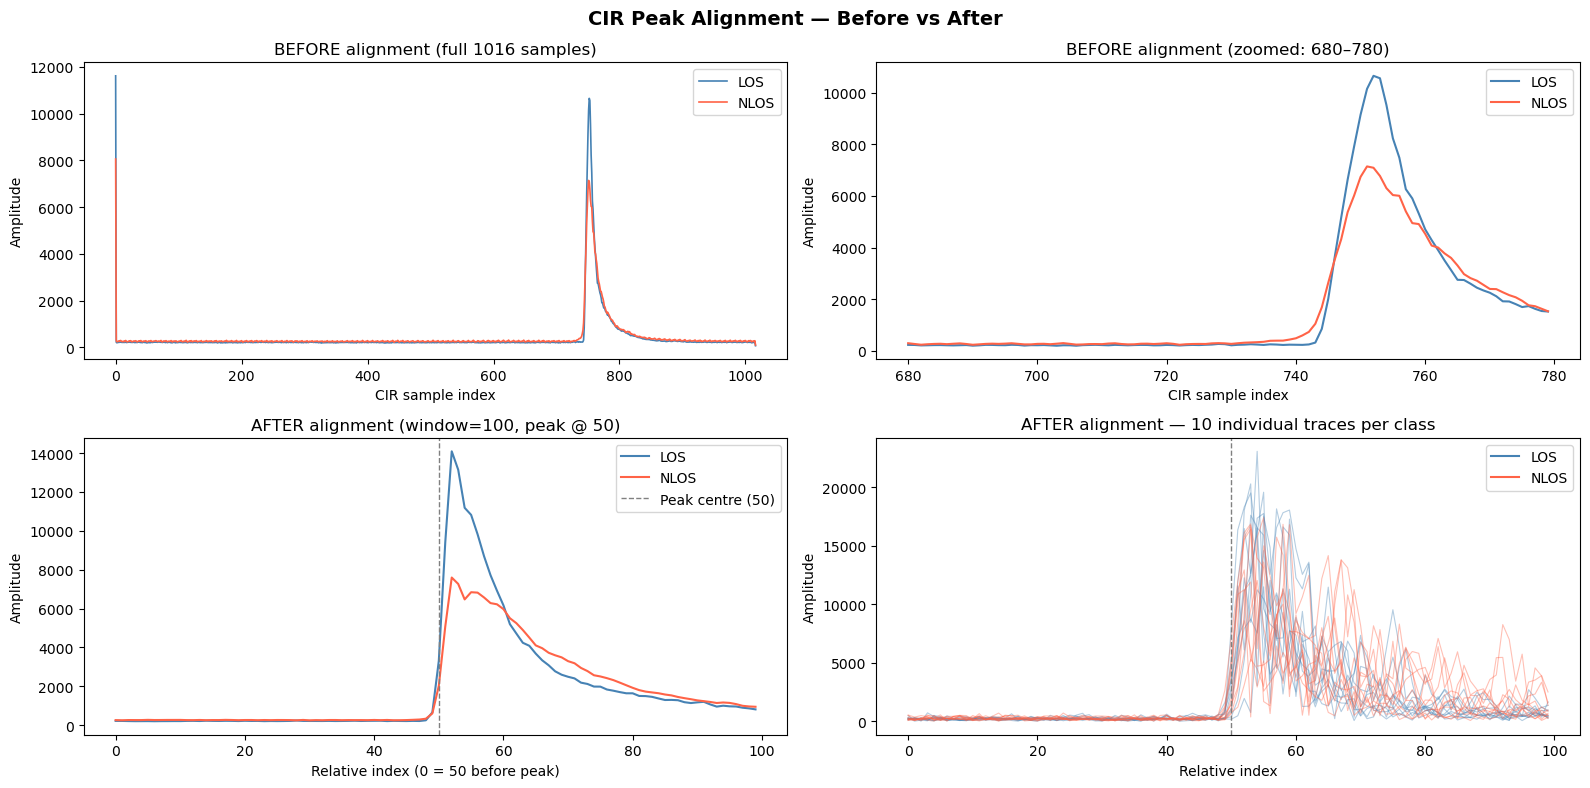

In [72]:
# ── 1. Pick sample indices by class ──────────────────────────────────────
y_vals = y.values  # NLOS labels (0=LOS, 1=NLOS)
los_idx  = np.where(y_vals == 0)[0]
nlos_idx = np.where(y_vals == 1)[0]

# Use first 500 samples of each class for speed
N = 500
los_sample  = los_idx[:N]
nlos_sample = nlos_idx[:N]

# ── 2. Raw CIR (unaligned) ───────────────────────────────────────────────
raw_cir = X_cir.values  # shape (42000, 1016)

raw_los_mean  = raw_cir[los_sample].mean(axis=0)
raw_nlos_mean = raw_cir[nlos_sample].mean(axis=0)

# ── 3. Aligned CIR ───────────────────────────────────────────────────────
aligned_los_mean  = X_cir_aligned[los_sample].mean(axis=0)
aligned_nlos_mean = X_cir_aligned[nlos_sample].mean(axis=0)

# ── 4. Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("CIR Peak Alignment — Before vs After", fontsize=14, fontweight='bold')

# --- Top left: Raw LOS vs NLOS (full 1016 width) ---
ax = axes[0, 0]
ax.plot(raw_los_mean,  label='LOS',  color='steelblue', linewidth=1.2)
ax.plot(raw_nlos_mean, label='NLOS', color='tomato',    linewidth=1.2)
ax.set_title("BEFORE alignment (full 1016 samples)")
ax.set_xlabel("CIR sample index")
ax.set_ylabel("Amplitude")
ax.legend()

# --- Top right: Raw — zoom in on peak region (index 680–780) ---
ax = axes[0, 1]
zoom = slice(680, 780)
ax.plot(range(680, 780), raw_los_mean[zoom],  label='LOS',  color='steelblue', linewidth=1.5)
ax.plot(range(680, 780), raw_nlos_mean[zoom], label='NLOS', color='tomato',    linewidth=1.5)
ax.set_title("BEFORE alignment (zoomed: 680–780)")
ax.set_xlabel("CIR sample index")
ax.set_ylabel("Amplitude")
ax.legend()

# --- Bottom left: Aligned LOS vs NLOS (window=100) ---
ax = axes[1, 0]
x_aligned = range(100)
ax.plot(x_aligned, aligned_los_mean,  label='LOS',  color='steelblue', linewidth=1.5)
ax.plot(x_aligned, aligned_nlos_mean, label='NLOS', color='tomato',    linewidth=1.5)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1, label='Peak centre (50)')
ax.set_title("AFTER alignment (window=100, peak @ 50)")
ax.set_xlabel("Relative index (0 = 50 before peak)")
ax.set_ylabel("Amplitude")
ax.legend()

# --- Bottom right: Overlay of 10 individual aligned traces per class ---
ax = axes[1, 1]
for i in los_sample[:10]:
    ax.plot(X_cir_aligned[i], color='steelblue', alpha=0.4, linewidth=0.8)
for i in nlos_sample[:10]:
    ax.plot(X_cir_aligned[i], color='tomato', alpha=0.4, linewidth=0.8)
ax.axvline(x=50, color='gray', linestyle='--', linewidth=1)
# Legend proxies
ax.legend(handles=[
    Line2D([0],[0], color='steelblue', label='LOS'),
    Line2D([0],[0], color='tomato',    label='NLOS'),
], loc='upper right')
ax.set_title("AFTER alignment — 10 individual traces per class")
ax.set_xlabel("Relative index")
ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

### SPLIT, SCALE & PCA
The dataset has two structurally different types of features that require separate
preprocessing pipelines. 
* The **14 summary signal features** are compact and physically meaningful, each representing a distinct property of the UWB signal. Therefore, only scaling is required.
  
* The **CIR columns**, however, is high-dimensional, redundant, and noisy. Thus, feature engineering is required to extract signal shape characteristics, scaling to normalise amplitudes, and PCA to compress the dimensionality before being usable for model training.

#### Find minimum PCs capturing highest variance
Before splitting, we fit PCA on the full scaled CIR to visualise how many components
are needed to retain 95% of the variance. This is used purely to determine `n_95`; the actual training PCA is fitted on train data only to prevent leakage.

<u>**Results**</u>  
The scree plot shows **81 components** is sufficient to capture 95% of CIR variance, reducing dimensions to a compact representation without significant information loss.

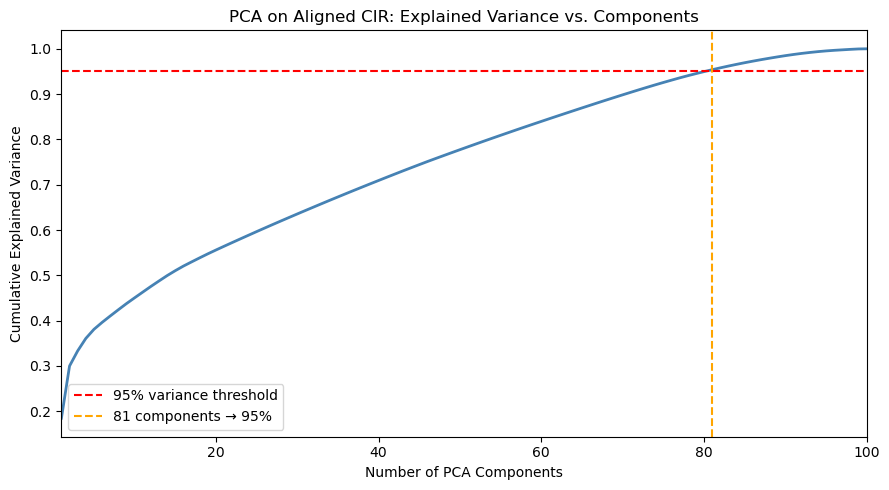

Components needed for 95% variance: 81


In [73]:
# Scale dataset
cir_scaler_explore = StandardScaler()
X_cir_aligned_scaled = cir_scaler_explore.fit_transform(X_cir_aligned)

# PCA explained variance curve — find minimum PC for highest variance capture
pca_full = PCA().fit(X_cir_aligned_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.searchsorted(cumvar, 0.95)) + 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='steelblue', linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
ax.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} components → 95%')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA on Aligned CIR: Explained Variance vs. Components')
ax.legend()
ax.set_xlim(1, 100)
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_95}")

#### Class Label Columns
We generate train and test indices using an 80/20 stratified split. A single set of indices (`train_idx`, `test_idx`) is used to slice labels, CIR, and signal features consistently, ensuring all three stay aligned. 

In [74]:
# Split ratio: 80/20
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y.values
)

# Train/Test split
y_train = y.values[train_idx]
y_test = y.values[test_idx]

#### CIR Columns
Using the indices from the split above, we separate the CIR waveforms into train and test sets, then apply three steps to the training data only:
1. **Feature engineering** on raw values: Extracts peak amplitude, total energy, kurtosis, and early/late energy ratio as compact descriptors of signal shape
   
2. **Scaling**: Standardises amplitudes before PCA so no sample dominates by magnitude alone
  
3. **PCA**: Compresses the waveform down to 81 components

The test set is transformed using the same fitted scaler and PCA.

<u>**Results**</u>  
CIR is reduced to **81 components** and **4 engineered features** per sample.
Both are carried forward to the final feature assembly step.

In [75]:
# Train/Test split
X_cir_train_raw = X_cir_aligned[train_idx]
X_cir_test_raw  = X_cir_aligned[test_idx]

# Feature engineer from raw (before scaling)
def extract_cir_features(X_raw):
    half         = X_raw.shape[1] // 2
    energy_early = (X_raw[:, :half] ** 2).sum(axis=1)
    energy_late  = (X_raw[:, half:] ** 2).sum(axis=1)
    energy_ratio = np.where(energy_late > 0, energy_early / energy_late, 0)
    return np.column_stack([
        X_raw.max(axis=1),
        (X_raw ** 2).sum(axis=1),
        np.array([scipy_kurtosis(row) for row in X_raw]),
        energy_ratio
    ])

X_cir_train_eng = extract_cir_features(X_cir_train_raw)
X_cir_test_eng  = extract_cir_features(X_cir_test_raw)

# Scale 
cir_scaler = StandardScaler()
X_cir_train_scaled = cir_scaler.fit_transform(X_cir_train_raw)
X_cir_test_scaled = cir_scaler.transform(X_cir_test_raw)    

eng_scaler = StandardScaler()
X_cir_train_eng_scaled = eng_scaler.fit_transform(X_cir_train_eng)
X_cir_test_eng_scaled  = eng_scaler.transform(X_cir_test_eng)

# PCA
pca = PCA(n_components=n_95, random_state=42)
X_cir_train_pca = pca.fit_transform(X_cir_train_scaled) 
X_cir_test_pca  = pca.transform(X_cir_test_scaled) 

print(f"CIR PCA            — Train: {X_cir_train_pca.shape} | Test: {X_cir_test_pca.shape}")
print(f"CIR Eng (scaled)   — Train: {X_cir_train_eng_scaled.shape}  | Test: {X_cir_test_eng_scaled.shape}")

CIR PCA            — Train: (33600, 81) | Test: (8400, 81)
CIR Eng (scaled)   — Train: (33600, 4)  | Test: (8400, 4)


#### Signal Features
Using the same indices, we split the 14 summary features and scale them using a separate scaler fitted on training data only. The scaled summary features, CIR PCA components, and CIR engineered features are then combined into a single feature matrix. `RANGE` is removed from the classifier inputs as it is the target variable for regression, keeping it would give the model an unfair advantage.

<u>**Results**</u>  
The final feature matrix combines all three components. 33,600 samples are assigned to training and 8,400 samples to testing, with both sets retaining a balanced **50/50 LOS/NLOS split**.

In [76]:
# Train/Test split
X_summary_train = X_summary.values[train_idx] # Unscaled; can be used for regression target
X_summary_test  = X_summary.values[test_idx] 

# Scale
summary_scaler = StandardScaler()
X_summary_train_scaled = summary_scaler.fit_transform(X_summary_train)
X_summary_test_scaled  = summary_scaler.transform(X_summary_test)

#Combine: 14 Summary features and PCA
X_train_combine = np.hstack([X_summary_train_scaled, X_cir_train_pca, X_cir_train_eng_scaled])
X_test_combine  = np.hstack([X_summary_test_scaled,  X_cir_test_pca,  X_cir_test_eng_scaled])

# Remove RANGE column from classifier features (index 0) to prevent leakage
range_idx = list(X_summary.columns).index('RANGE')  
clf_feat_idx = [i for i in range(X_train_combine.shape[1]) if i != range_idx]
X_train_final = X_train_combine[:, clf_feat_idx]
X_test_final = X_test_combine[:,  clf_feat_idx]

# Feature names
pca_names      = [f'PCA_{i}' for i in range(X_cir_train_pca.shape[1])]
eng_names      = ['CIR_peak', 'CIR_energy', 'CIR_kurtosis', 'CIR_energy_ratio']
all_feat_names = list(X_summary.columns) + pca_names + eng_names
clf_feat_names = [all_feat_names[i] for i in clf_feat_idx]

print(f"Train: {X_train_final.shape} | Test: {X_test_final.shape}")
print(f"\nTrain — LOS: {(y_train==0).sum()} | NLOS: {(y_train==1).sum()}")
print(f"Test  — LOS: {(y_test==0).sum()}  | NLOS: {(y_test==1).sum()}")

Train: (33600, 98) | Test: (8400, 98)

Train — LOS: 16800 | NLOS: 16800
Test  — LOS: 4200  | NLOS: 4200


## CLASSIFICATION MODEL
---
In this section we tackle the first problem of determining if a signal is LOS or NLOS based on it's properties.

### MULTI-MODEL COMPARISON
We evaluate four classifiers representing a range of model complexity, using 5-fold stratified cross-validation on the training set, measuring AUC-ROC, accuracy, and F1 score. Cross-validation gives a more reliable performance estimate than a single train/test split by averaging results across 5 different data subsets.

1. **Logistic Regression**: Linear baseline; establishes the minimum performance a non-linear model must exceed to justify its added complexity
  
2.  **KNN (k=5)**: Non-linear, instance-based; classifies by proximity to neighbours in feature space

3. **Random Forest**: Ensemble of decision trees; captures non-linear boundaries through majority voting across many trees

4. **XGBoost**: Gradient boosted trees; sequentially corrects errors of previous trees, typically the strongest performer on tabular data

<u>**Results**</u>  
* XGBoost achieves the highest AUC-ROC (**0.9488**), followed closely by
Random Forest (**0.9389**), Logistic Regression (**0.9268**), and KNN (**0.8804**).  
  
* The performance gap between the linear model (Logistic Regression) and the two
tree-based models confirms the data exploration finding that LOS/NLOS classes are not linearly separable.  
  
* KNN underperforms relative to the ensemble methods, likely due to its sensitivity to the high-dimensional feature space even after PCA reduction. 
  
* **XGBoost is selected** as the final classifier for its highest AUC and F1, and
reasonable training time (31.7s vs 178.6s for Random Forest).

In [100]:
# Multi-model comparison across 4 classification models
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN (k=5)'          : KNeighborsClassifier(n_neighbors=5),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(n_estimators=200, max_depth=6, random_state=42, 
                                         verbosity=0, n_jobs=1),
}

# Calculate results for each model
clf_results = []
for name, clf in classifiers.items():
    t0  = time.time()
    cv  = cross_validate(clf, X_train_final, y_train, cv=5,
                     scoring=['roc_auc', 'accuracy', 'f1'], n_jobs=-1) # Standard evaluation metrics
    elapsed = time.time() - t0 # Time taken for training
    
    clf_results.append({
        'Model'   : name,
        'AUC-ROC' : round(cv['test_roc_auc'].mean(),  4),
        'AUC±std' : round(cv['test_roc_auc'].std(),   4),
        'Accuracy': round(cv['test_accuracy'].mean(),  4),
        'F1'      : round(cv['test_f1'].mean(),        4),
        'Time(s)' : round(elapsed, 1)
    })
    
    print(f"{name:25s} | AUC={cv['test_roc_auc'].mean():.4f}±{cv['test_roc_auc'].std():.4f} | "
          f"Acc={cv['test_accuracy'].mean():.4f} | F1={cv['test_f1'].mean():.4f} | {elapsed:.1f}s")

clf_results_df = pd.DataFrame(clf_results).sort_values('AUC-ROC', ascending=False)
display(clf_results_df)

Logistic Regression       | AUC=0.9268±0.0052 | Acc=0.8588 | F1=0.8527 | 8.1s
KNN (k=5)                 | AUC=0.8804±0.0036 | Acc=0.8246 | F1=0.8134 | 18.8s
Random Forest             | AUC=0.9389±0.0049 | Acc=0.8776 | F1=0.8726 | 111.8s
XGBoost                   | AUC=0.9488±0.0043 | Acc=0.8825 | F1=0.8786 | 24.8s


,Model,AUC-ROC,AUC±std,Accuracy,F1,Time(s)
3,XGBoost,0.9488,0.0043,0.8825,0.8786,24.8
2,Random Forest,0.9389,0.0049,0.8776,0.8726,111.8
0,Logistic Regression,0.9268,0.0052,0.8588,0.8527,8.1
1,KNN (k=5),0.8804,0.0036,0.8246,0.8134,18.8


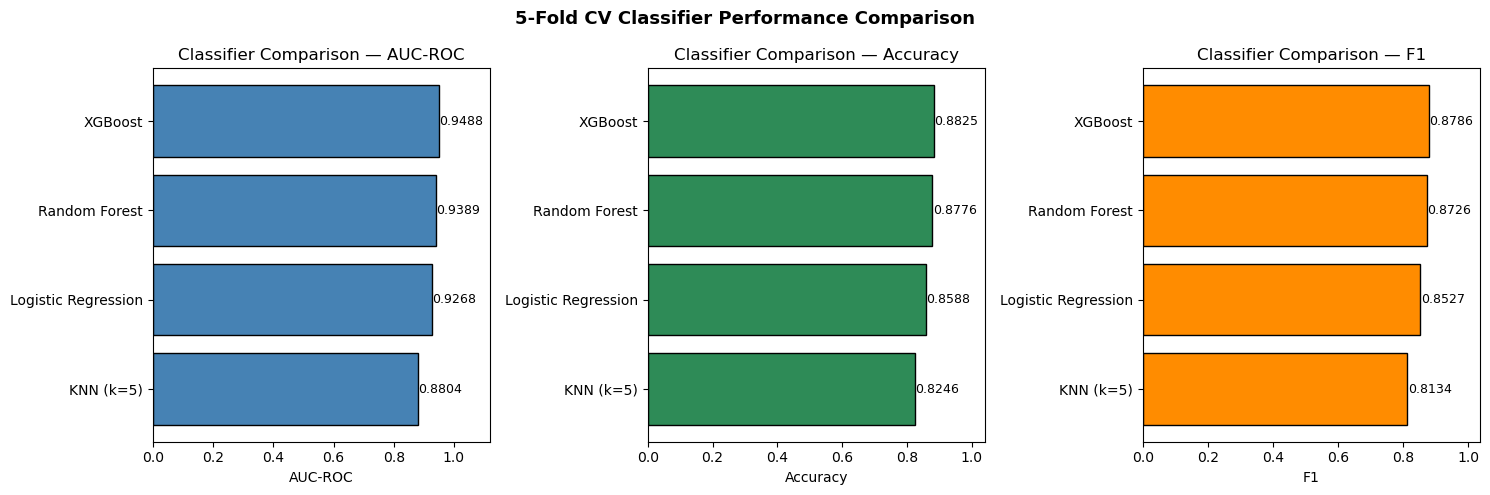

In [101]:
# Bar chart to visualise model performance
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['AUC-ROC', 'Accuracy', 'F1']
colors  = ['steelblue', 'seagreen', 'darkorange']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = clf_results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric],
                   color=color, edgecolor='black')
    ax.set_xlabel(metric)
    ax.set_title(f'Classifier Comparison — {metric}')
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    ax.set_xlim(0, sorted_df[metric].max() * 1.18 )

plt.suptitle('5-Fold CV Classifier Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### MODEL TRAINING
After selecting the best model for the classification task, we determine the hyperparameter values for optimal performance and use it for the actual model training while ensuring that we avoid under/overfitting.

#### Find Best Iteration
We carve out 10% of the training set as a validation set, only to be used for early stopping. XGBoost is configured to train up to 1,000 boosting rounds but monitors log loss on the validation set after each round. If no improvement is seen for 30 consecutive rounds, training stops automatically and the best iteration is recorded.

<u>**Results**</u>  
Training stopped at round **338 out of 1,000**, meaning additional trees would have added no improvement and likely caused overfitting. This iteration count will be used for final training.

In [79]:
# Create validation set for early stopping (NOT for final evaluation)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_train, test_size=0.1, stratify=y_train, random_state=42
)

# Main model with early stopping -> Find optimal n_estimators
xgb_clf = xgb.XGBClassifier(
    n_estimators=1000, # Set high to find early stopping count
    learning_rate=0.05, # Standard starting value; Lower = more trees needed but better generalisation
    max_depth=5, 
    min_child_weight=5, # Minimum samples per leaf; Higher = more conservative, reduce overfitting
    subsample=0.8, 
    colsample_bytree=0.8,
    colsample_bylevel=0.8,
    reg_lambda=1.5, 
    reg_alpha=0.05, 
    scale_pos_weight=1.3, 
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1,
    early_stopping_rounds=30 # Stop after 30 rounds with no improvement
)

xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {xgb_clf.best_iteration}")

Best iteration: 338


#### Find best depth
We then determine the optimal max depth each decision tree can grow. A shallow tree underfits and cannot capture complex patterns. A tree that is too deep overfits, memorising  training noise rather than learning general patterns. Thus, a balanced must be striked.  
  
We test depths from 2 to 9 using 3-fold cross-validation and select the knee point (where performance stops
meaningfully improving).

<u>**Results**</u>  
CV AUC-ROC rises steeply from depth 2 to around depth 6, then the gains become negligible. The knee-point detection identifies **`max_depth = 7`** as the point where each additional level of depth improves AUC by less than 0.1%, making deeper trees not worth the added complexity. **`max_depth = 7`** is used for the final model.

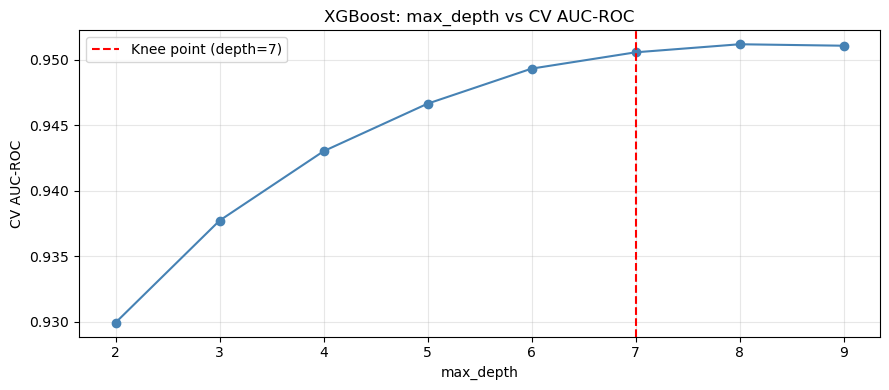

Best max_depth (knee point): 7  (CV AUC = 0.9506)


In [80]:
depths = range(2, 10)
cv_scores = []

# Evaluate performance for each depth
for d in depths:
    m = xgb.XGBClassifier(max_depth=d, n_estimators=100,
                           learning_rate=0.05, random_state=42,
                           verbosity=0, n_jobs=-1)
    scores = cross_val_score(m, X_train_final, y_train, cv=3,
                             scoring='roc_auc')
    cv_scores.append(scores.mean())

# Find knee point: The first depth where marginal gain drops below threshold
threshold = 0.001  # less than 0.1% improvement = diminishing returns
best_depth = list(depths)[0]
for i in range(1, len(cv_scores)):
    if cv_scores[i] - cv_scores[i - 1] < threshold:
        best_depth = list(depths)[i - 1]
        break
else:
    best_depth = list(depths)[np.argmax(cv_scores)]

plt.figure(figsize=(9, 4))
plt.plot(depths, cv_scores, marker='o', color='steelblue')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Knee point (depth={best_depth})')
plt.xlabel('max_depth')
plt.ylabel('CV AUC-ROC')
plt.title('XGBoost: max_depth vs CV AUC-ROC')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best max_depth (knee point): {best_depth}  (CV AUC = {cv_scores[list(depths).index(best_depth)]:.4f})")

#### Train XGBoost Classifier
We retrain XGBoost on the full training set. The hyperparameters are near-default standard values of XGBoost, while `max_depth` and `n_estimators` values were selected from the empirical testing earlier. We then evaluate using 5-fold cross-validation to confirm consistent performance across different data subsets.

<u>**Results**</u>  
The model achieves a **CV ROC-AUC of 0.9526 ± 0.0039** across 5 folds. The small standard deviation (±0.0039) confirms that performance is stable and consistent; the model is not sensitive to the portion of data it is evaluated on.

In [81]:
# CV model using best iteration
xgb_cv = xgb.XGBClassifier(
    n_estimators=xgb_clf.best_iteration,
    learning_rate=0.05, 
    max_depth=best_depth, 
    min_child_weight=5,
    subsample=0.8, 
    colsample_bytree=0.8, 
    colsample_bylevel=0.8,
    reg_lambda=1.5, 
    reg_alpha=0.05, 
    scale_pos_weight=1.3,
    random_state=42, 
    eval_metric='logloss', 
    verbosity=0, 
    n_jobs=-1
)

cv_scores = cross_val_score(xgb_cv, X_train_final, y_train, cv=5, scoring='roc_auc')
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC: 0.9526 ± 0.0039


#### Check for under/overfitting
We compare training and test AUC scores to verify the model generalises to unseen data. A large gap would indicate the model memorised the training set rather than learning the general patterns in the data.

<u>**Results**</u>  
The gap between train and test AUC is only **0.0265**, which is well within the acceptable range. The model is assessed as **HEALTHY**, meaning it has genuinely learned the difference between LOS and NLOS signals rather than memorising the training data.

In [102]:
# Check for underfit/overfit
y_pred_prob = xgb_clf.predict_proba(X_test_final)[:, 1]
train_auc   = roc_auc_score(y_train, xgb_clf.predict_proba(X_train_final)[:, 1])
test_auc    = roc_auc_score(y_test,  y_pred_prob)
gap         = train_auc - test_auc

print(f"\n{'='*45}")
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"{'='*45}")
print(f"{'ROC-AUC':<20} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Gap':<20} {gap:>10.4f}")
print(f"{'='*45}")

if train_auc < 0.90:
    print("UNDERFITTING — relax regularisation")
elif gap > 0.05:
    print("OVERFITTING — increase regularisation or reduce depth")
else:
    print("HEALTHY — good generalisation")


Metric                    Train       Test
ROC-AUC                  0.9764     0.9499
Gap                      0.0265
HEALTHY — good generalisation


### PERFORMANCE EVALUATION
We produce a full visual dashboard to assess the tuned classifier from multiple angles: 
* **Threshold tuning**
* **Confusion matrix**
* **ROC curve**
* **Precision-Recall curve**

Additionally, we plotted a bar chart to identify the **Top 20 features** that influenced model performance.

<u>**Results**</u>  
* The optimal threshold is **0.440**, yielding near-balanced recalls of **LOS: 0.8781** and **NLOS: 0.8769** (gap: 0.0012).
  
* The confusion matrix shows **3,668 correct LOS** and **3,663 correct NLOS** predictions out of 4,200 samples each, confirming strong and balanced classification.
   
* The **Test ROC-AUC of 0.9499** and **Average Precision (AP) of 0.9568** further confirm that the model reliably separates LOS from NLOS across all possible thresholds.
  
* Among all input features, **`CIR_peak`** is the most important by a large margin, followed by `RXPACC`, and `CIR_kurtosis`. This validates that the CIR-derived features carry the most discriminative power for LOS/NLOS classification.

Optimal threshold: 0.440
  LOS recall  : 0.8781
  NLOS recall : 0.8769
  Recall gap  : 0.0012
  Accuracy    : 0.8775

Tuned XGBoost Classification Report (threshold = 0.440):

              precision    recall  f1-score   support

         LOS       0.88      0.88      0.88      4200
        NLOS       0.88      0.88      0.88      4200

    accuracy                           0.88      8400
   macro avg       0.88      0.88      0.88      8400
weighted avg       0.88      0.88      0.88      8400

Tuned Accuracy : 0.8775
Test ROC-AUC   : 0.9499
CV ROC-AUC     : 0.9526 ± 0.0039


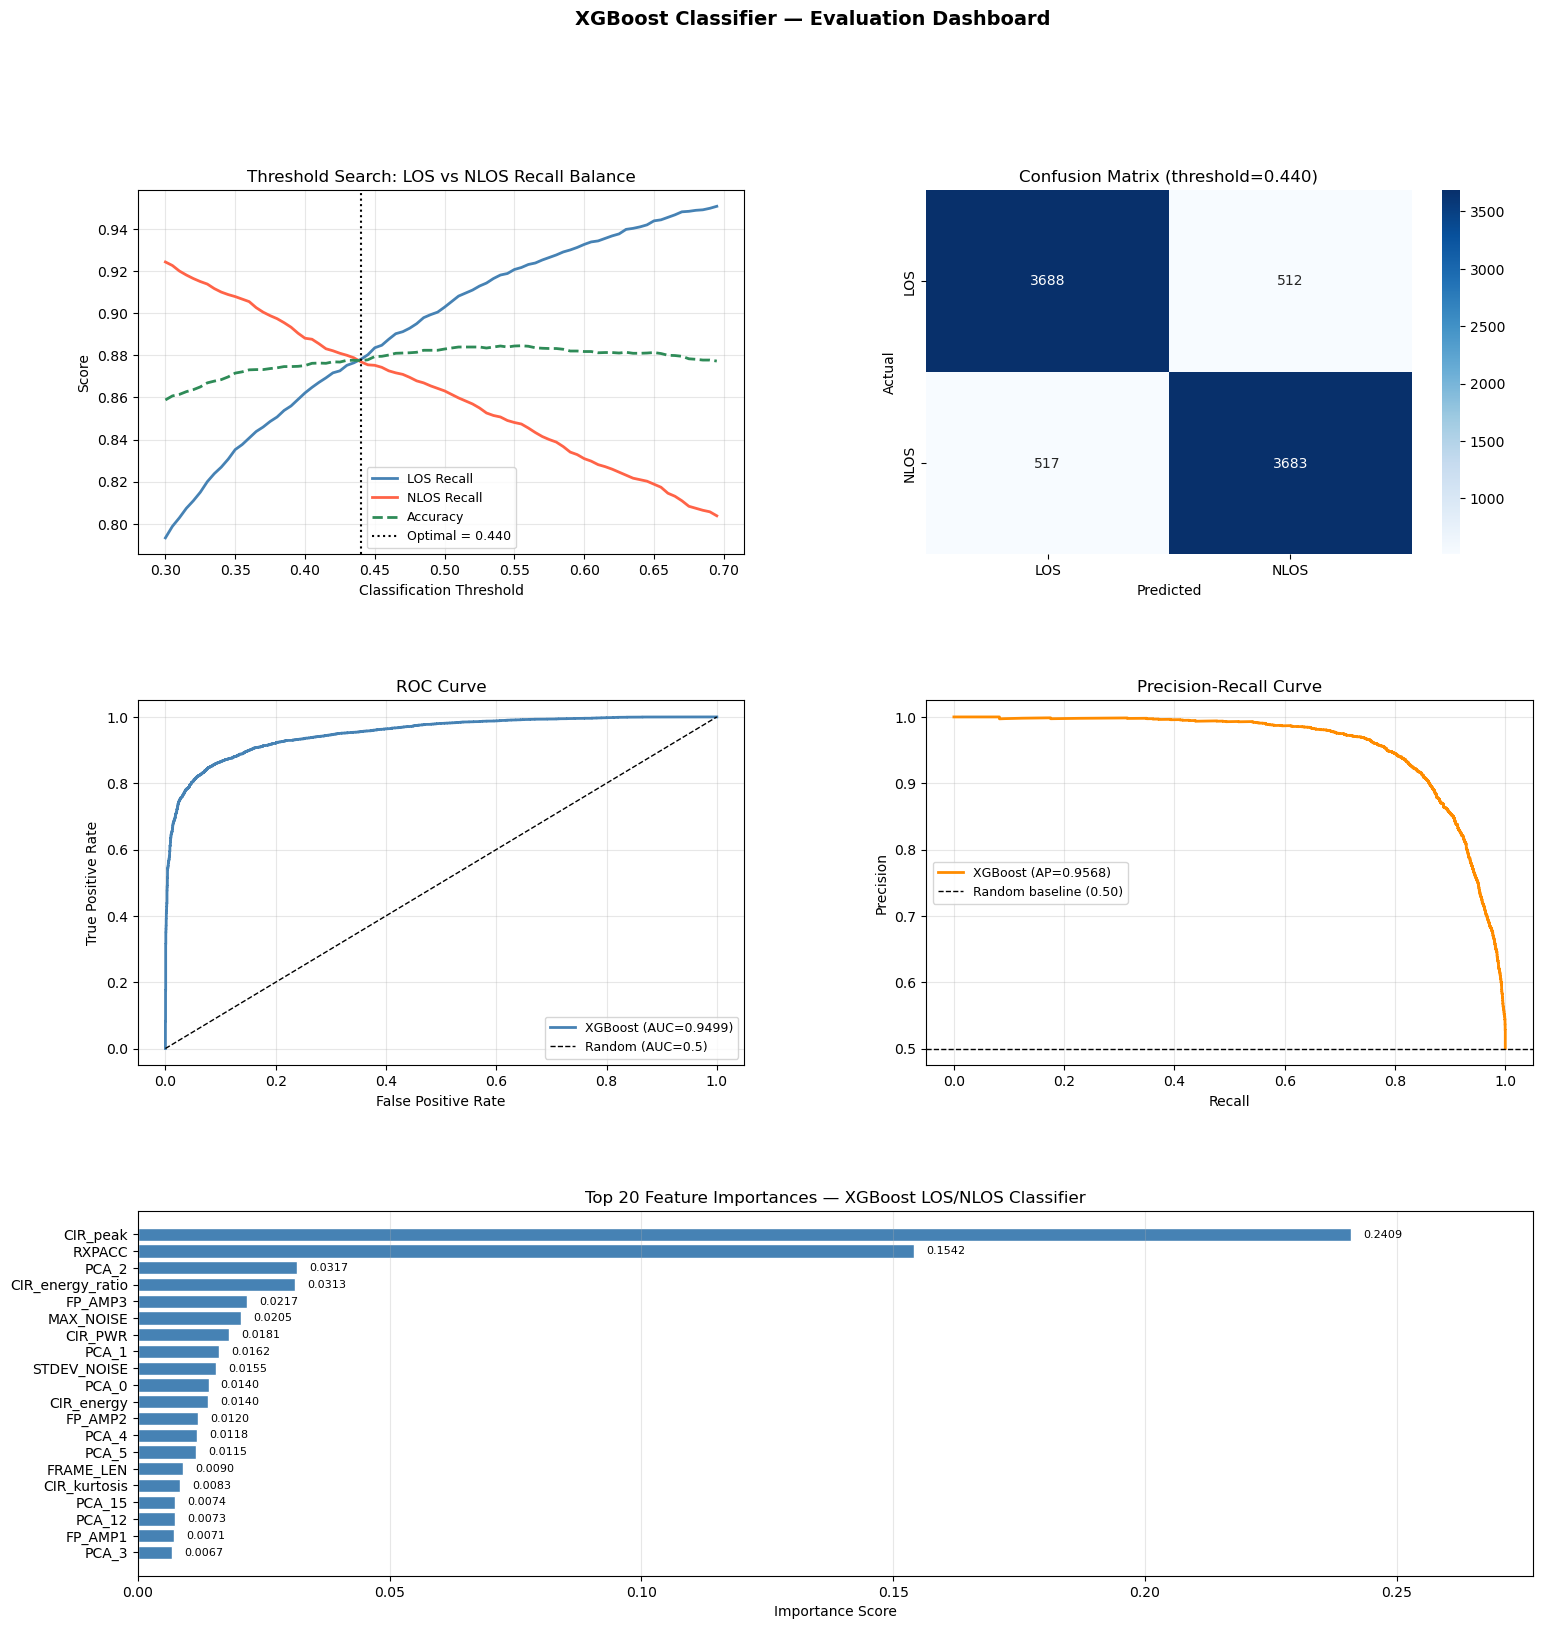

In [83]:
# Find threshold that equalises LOS and NLOS recall
thresholds = np.arange(0.30, 0.70, 0.005)
results = []
for t in thresholds:
    preds       = (y_pred_prob >= t).astype(int)
    los_recall  = recall_score(y_test, preds, pos_label=0)
    nlos_recall = recall_score(y_test, preds, pos_label=1)
    macro_f1    = f1_score(y_test, preds, average='macro')
    acc         = (preds == y_test).mean()
    results.append((t, los_recall, nlos_recall, macro_f1, acc))

results_df = pd.DataFrame(results,
    columns=['threshold', 'LOS_recall', 'NLOS_recall', 'macro_f1', 'accuracy'])
results_df['recall_gap'] = abs(results_df['LOS_recall'] - results_df['NLOS_recall'])
best_row    = results_df.loc[results_df['recall_gap'].idxmin()]
best_thresh = best_row['threshold']

y_pred_tuned = (y_pred_prob >= best_thresh).astype(int)
test_auc     = roc_auc_score(y_test, y_pred_prob)

print(f"Optimal threshold: {best_thresh:.3f}")
print(f"  LOS recall  : {best_row['LOS_recall']:.4f}")
print(f"  NLOS recall : {best_row['NLOS_recall']:.4f}")
print(f"  Recall gap  : {best_row['recall_gap']:.4f}")
print(f"  Accuracy    : {best_row['accuracy']:.4f}\n")
print(f"Tuned XGBoost Classification Report (threshold = {best_thresh:.3f}):\n")
print(classification_report(y_test, y_pred_tuned, target_names=['LOS', 'NLOS']))
print(f"Tuned Accuracy : {(y_pred_tuned == y_test).mean():.4f}")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"CV ROC-AUC     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Dashboard
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# Threshold Search Plot
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(results_df['threshold'], results_df['LOS_recall'],
         color='steelblue', lw=2, label='LOS Recall')
ax1.plot(results_df['threshold'], results_df['NLOS_recall'],
         color='tomato', lw=2, label='NLOS Recall')
ax1.plot(results_df['threshold'], results_df['accuracy'],
         color='seagreen', lw=2, linestyle='--', label='Accuracy')
ax1.axvline(best_thresh, color='black', linestyle=':', lw=1.5,
            label=f'Optimal = {best_thresh:.3f}')
ax1.set_xlabel('Classification Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold Search: LOS vs NLOS Recall Balance')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Confusion Matrix 
ax2  = fig.add_subplot(gs[0, 1])
cm   = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOS', 'NLOS'],
            yticklabels=['LOS', 'NLOS'], ax=ax2)
ax2.set_title(f'Confusion Matrix (threshold={best_thresh:.3f})')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# ROC Curve
ax3       = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax3.plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC={test_auc:.4f})')
ax3.plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.5)')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# Precision-Recall Curve 
ax4 = fig.add_subplot(gs[1, 1])
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ap       = average_precision_score(y_test, y_pred_prob)
baseline = y_test.mean()
ax4.plot(recall, precision, color='darkorange', lw=2, label=f'XGBoost (AP={ap:.4f})')
ax4.axhline(baseline, color='k', linestyle='--', lw=1,
            label=f'Random baseline ({baseline:.2f})')
ax4.set_xlabel('Recall')
ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall Curve')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# Feature Importance 
ax5 = fig.add_subplot(gs[2, :])
assert len(clf_feat_names) == len(xgb_clf.feature_importances_), \
    f"Mismatch: {len(clf_feat_names)} names vs {len(xgb_clf.feature_importances_)} importances"

feat_imp_df = pd.DataFrame({
    'Feature'   : clf_feat_names,
    'Importance': xgb_clf.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

x_max = feat_imp_df['Importance'].max()
bars  = ax5.barh(feat_imp_df['Feature'][::-1],
                 feat_imp_df['Importance'][::-1],
                 color='steelblue', edgecolor='white')
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax5.text(val + x_max * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=8)
ax5.set_xlim(0, x_max + x_max * 0.15)
ax5.set_xlabel('Importance Score')
ax5.set_title('Top 20 Feature Importances — XGBoost LOS/NLOS Classifier')
ax5.grid(axis='x', alpha=0.3)

plt.suptitle('XGBoost Classifier — Evaluation Dashboard', fontsize=14, fontweight='bold')
plt.show()

### SUMMARY REPORT
A summary of all key metrics for the tuned XGBoost classifier.

<u>**Results**</u>  
The model performs almost equally well on both training and unseen test data, and correctly identifies LOS and NLOS signals at nearly the same rate. This ensures the model doesn't perform better at classifying one type of signal which could skew distance estimates later.

In [84]:
los_rec  = recall_score(y_test, y_pred_tuned, pos_label=0)
nlos_rec = recall_score(y_test, y_pred_tuned, pos_label=1)
rec_gap  = abs(los_rec - nlos_rec)
accuracy = (y_pred_tuned == y_test).mean()
clf_gap  = train_auc - test_auc

print("=" * 50)
print("       FINAL CLASSIFIER SUMMARY")
print("=" * 50)
print(f"Model              : XGBoost Classifier")
print(f"Trees used         : {xgb_clf.best_iteration} / 1000")
print(f"Decision threshold : {best_thresh:.3f}")
print(f"CV ROC-AUC         : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Train ROC-AUC      : {train_auc:.4f}")
print(f"Test  ROC-AUC      : {test_auc:.4f}")
print(f"Generalisation gap : {clf_gap:.4f}  ({'HEALTHY' if abs(clf_gap) < 0.05 else 'CHECK OVERFIT'})")
print(f"Final Accuracy     : {accuracy:.4f}")
print("-" * 50)
print(f"LOS  recall        : {los_rec:.4f}")
print(f"NLOS recall        : {nlos_rec:.4f}")
print(f"Recall gap         : {rec_gap:.4f}")
print("=" * 50)

       FINAL CLASSIFIER SUMMARY
Model              : XGBoost Classifier
Trees used         : 338 / 1000
Decision threshold : 0.440
CV ROC-AUC         : 0.9526 ± 0.0039
Train ROC-AUC      : 0.9764
Test  ROC-AUC      : 0.9499
Generalisation gap : 0.0265  (HEALTHY)
Final Accuracy     : 0.8775
--------------------------------------------------
LOS  recall        : 0.8781
NLOS recall        : 0.8769
Recall gap         : 0.0012


## REGRESSION MODEL
---
In this section, we tackle the second part to the problem, predicting how far off the raw UWB distance reading is so it can be corrected.

### FEATURE PREPARATION
Before training the regressor, we enrich the feature set with two additions:
1. **NLOS probability**: How confident the classifier model is that the signal is NLOS
  
2. **A per-bin error target**: The difference between each raw range reading and the typical LOS reading at that distance range
  
The error target is computed by grouping LOS training samples into 1-metre-wide bins spanning the observed range (0-9m), and taking the LOS median of each bin. Each sample's target is `raw_range − its bin's LOS median`. A global LOS median would have introduced distance-dependent noise while per-bin medians isolates genuine ranging error from distance variation. This ensures every sample is compared against a reference appropriate for its own distance range.  
  
<u>**Results**</u>  
The augmented feature matrix adds one column `nlos_pred` to the original features, giving the regressor both signal characteristics and classifier confidence as inputs. By comparing error standard deviations before and after per-bin medians, we confirm that it produces a cleaner target than global median.

In [85]:
# Strip early_stopping_rounds by creating a clean version of the classifier
xgb_clf_infer = clone(xgb_clf)
xgb_clf_infer.set_params(early_stopping_rounds=None)

# Calculate probability of NLOS
nlos_prob_train_oof = cross_val_predict(
    xgb_clf_infer, X_train_final, y_train,
    cv=5, method='predict_proba', n_jobs=-1
)[:, 1]
nlos_prob_test = xgb_clf.predict_proba(X_test_final)[:, 1]

# Augment feature matrices
X_train_aug = np.hstack([X_train_final, nlos_prob_train_oof.reshape(-1, 1)])
X_test_aug  = np.hstack([X_test_final,  nlos_prob_test.reshape(-1, 1)])

# Creating bins from LOS range
los_ranges = X_summary_train[y_train == 0, 0]
# bins = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, np.inf]
range_max = np.ceil(los_ranges.max())  # = 9.0
bins = [float(x) for x in np.arange(0, range_max, 1.0)] + [float(range_max)]

# Compute LOS median per distance bin
bin_medians = {}
for i in range(len(bins) - 1):
    mask = (los_ranges >= bins[i]) & (los_ranges < bins[i+1])
    if mask.sum() >= 1:
        bin_medians[i] = np.median(los_ranges[mask])

global_fallback = np.median(los_ranges)  # fallback if bin is empty

def assign_ref(ranges):
    refs = np.full(len(ranges), global_fallback)
    for i in range(len(bins) - 1):
        mask = (ranges >= bins[i]) & (ranges < bins[i+1])
        refs[mask] = bin_medians.get(i, global_fallback)
    return refs

y_error_train = X_summary_train[:, 0] - assign_ref(X_summary_train[:, 0])
y_error_test  = X_summary_test[:, 0]  - assign_ref(X_summary_test[:, 0])

print(f"Range: {los_ranges.min():.1f}m – {los_ranges.max():.1f}m → Bins: {bins}")
print("Per-bin LOS medians:", {k: round(float(v), 2) for k, v in bin_medians.items()})
print(f"\nAugmented train shape: {X_train_aug.shape}")
print(f"Augmented test  shape: {X_test_aug.shape}")
print(f"\nLOS median range: {global_fallback:.3f} m")
print(f"\nError target (Train): mean={y_error_train.mean():.3f}m  std={y_error_train.std():.3f}m")
print(f"Error target  (Test): mean={y_error_test.mean():.3f}m  std={y_error_test.std():.3f}m")

Range: 0.0m – 8.3m → Bins: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
Per-bin LOS medians: {0: 0.74, 1: 1.46, 2: 2.46, 3: 3.49, 4: 4.52, 5: 5.41, 6: 6.34, 7: 7.28, 8: 8.33}

Augmented train shape: (33600, 99)
Augmented test  shape: (8400, 99)

LOS median range: 2.430 m

Error target (Train): mean=0.268m  std=1.337m
Error target  (Test): mean=0.264m  std=1.309m


### MULTI-MODEL COMPARISON
We evaluate four regression models across a range of  complexity using 5-fold cross-validation on the training set, measuring RMSE and MAE. Cross-validation gives a more reliable performance estimate than a single train/test split by averaging results across 5 different data subsets.

1. **Linear Regression**: Linear baseline; establishes the minimum performance a non-linear model must exceed to justify its added complexity
  
2.  **KNN Regressor (k=5)**: Non-linear, instance-based; predicts by averaging the target values of the nearest neighbours in feature space
  
3. **Random Forest Regressor**: Ensemble of decision trees; captures non-linear patterns through averaging predictions across many trees
  
4. **XGBoost Regressor**: Gradient boosted trees; sequentially corrects errors of previous trees, typically the strongest performer on tabular data
  
<u>**Results**</u>  
* Random Forest and Gradient Boosting achieve the lowest CV RMSE (**1.0156m** and **1.0158m** respectively), followed closely by XGBoost (**1.0285m**) and Ridge (**1.1634m**).

* The performance gap between Ridge and the three non-linear models confirms that ranging error is non-linearly related to the input features. Thus, a linear model alone is insufficient for this correction task.

* The RMSE difference between Random Forest, Gradient Boosting, and XGBoost is only **0.013m**, making the three models statistically equivalent in performance.

* **XGBoost is selected** as the final regressor despite marginally higher RMSE, due to its **faster training time** (22.9s vs 462.6s for Random Forest), making iterative hyperparameter tuning practical with negligible performance sacrifice.

<div style="background:#f0f0f0; border-left:4px solid #999; padding:10px; border-radius:3px;">
<strong>Note on R² ≈ 0.42:</strong> The model explains about 42% of the variation in ranging error. The remaining 58% comes from random signal noise caused by reflections and obstacles; information that simply isn't captured in the signal features. Despite this, the model is still practically useful. It reduces the typical error from <strong>3–5m</strong> (uncorrected NLOS) down to <strong>~1.0m RMSE</strong>, which is a significant improvement for UWB positioning.
</div>

In [98]:
# Regression models to compare
regressors = {
    'Ridge'             : Ridge(),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=50, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, max_depth=6, random_state=42,
                                       verbosity=0, n_jobs=1),
}

reg_results = []
for name, reg in regressors.items():
    t0 = time.time()
    cv = cross_validate(reg, X_train_aug, y_error_train, cv=5,
                        scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'], # Standard evaluation metrics
                        n_jobs=-1)
    elapsed = time.time() - t0 # Time it takes to train
    
    reg_results.append({
        'Model':    name,
        'RMSE':     round(-cv['test_neg_root_mean_squared_error'].mean(), 4),
        'RMSE_std': round(cv['test_neg_root_mean_squared_error'].std(),  4),
        'MAE':      round(-cv['test_neg_mean_absolute_error'].mean(),  4),
        'R²':       round(cv['test_r2'].mean(),   4),
        'Time_s':   round(elapsed, 1),
    })
    
    print(f"{name:25s} | RMSE={-cv['test_neg_root_mean_squared_error'].mean():.4f}"
          f"(±{cv['test_neg_root_mean_squared_error'].std():.4f})m | "
          f"MAE={-cv['test_neg_mean_absolute_error'].mean():.4f}m | "
          f"R²={cv['test_r2'].mean():.4f} | {elapsed:.1f}s")

reg_results_df = pd.DataFrame(reg_results).sort_values('RMSE')
display(reg_results_df)

Ridge                     | RMSE=1.1634(±0.0188)m | MAE=0.5747m | R²=0.2431 | 12.1s
Random Forest             | RMSE=1.0156(±0.0257)m | MAE=0.4691m | R²=0.4229 | 599.1s
Gradient Boosting         | RMSE=1.0158(±0.0216)m | MAE=0.4645m | R²=0.4229 | 214.6s
XGBoost                   | RMSE=1.0285(±0.0213)m | MAE=0.4839m | R²=0.4083 | 20.4s


,Model,RMSE,RMSE_std,MAE,R²,Time_s
1,Random Forest,1.0156,0.0257,0.4691,0.4229,599.1
2,Gradient Boosting,1.0158,0.0216,0.4645,0.4229,214.6
3,XGBoost,1.0285,0.0213,0.4839,0.4083,20.4
0,Ridge,1.1634,0.0188,0.5747,0.2431,12.1


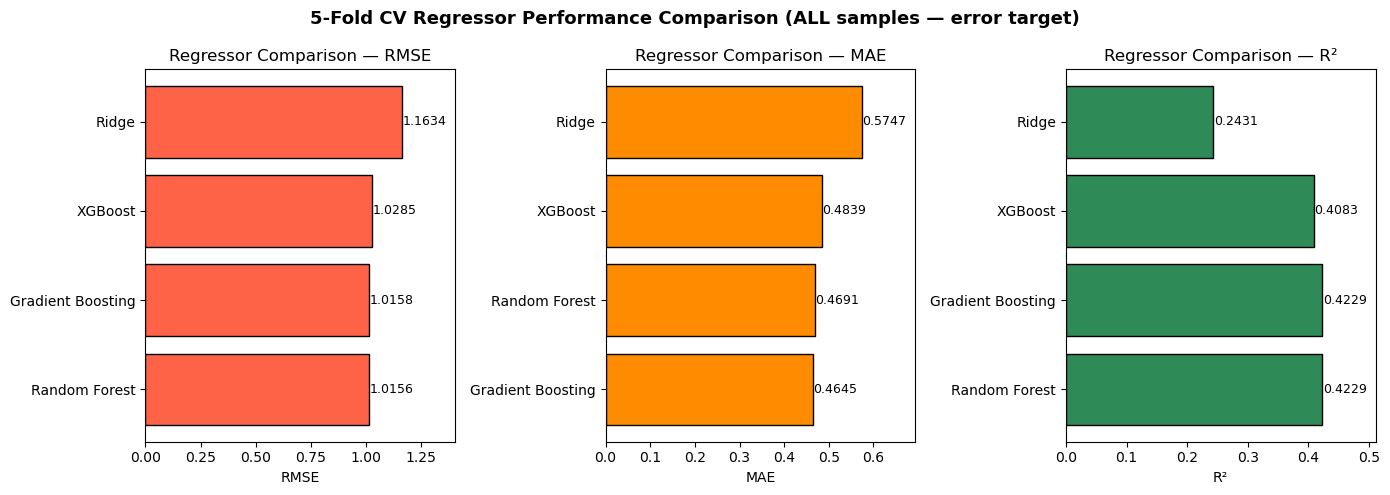

In [99]:
# Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

reg_metrics = ['RMSE', 'MAE', 'R²']
reg_colors  = ['tomato', 'darkorange', 'seagreen']

for ax, metric, color in zip(axes, reg_metrics, reg_colors):
    sorted_df = reg_results_df.sort_values(metric, ascending=(metric != 'R²'))
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, edgecolor='black')
    ax.set_xlabel(metric)
    ax.set_title(f'Regressor Comparison — {metric}')
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

plt.suptitle('5-Fold CV Regressor Performance Comparison (ALL samples — error target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_regressor_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### MODEL TRAINING

#### Find best iteration
XGBoost builds trees one by one, and too many trees eventually cause overfitting. We train up to 1,000 trees and monitor performance on a held-out validation set after every round; stopping automatically when no improvement is seen for 30 consecutive rounds.

<u>**Results**</u>  
Training stopped at **149 trees**. Additional trees would have added overfitting without improving accuracy. This
count is used for all subsequent training.

In [88]:
# Split Training into Train and Validation set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_error_train, test_size=0.1, random_state=42
)

# Find best n_estimators
xgb_reg = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    reg_lambda            = 1.5,
    reg_alpha             = 0.05,
    random_state          = 42,
    eval_metric           = 'rmse',
    verbosity             = 0,
    n_jobs                = -1,
    early_stopping_rounds = 30,
)

xgb_reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
best_iter = xgb_reg.best_iteration
print(f"Best iteration (early stopping): {best_iter}")

Best iteration (early stopping): 149


#### Find best depth
`max_depth` controls how detailed each decision tree can grow. Too shallow and the model misses real patterns. Too deep and it memorises noise. We sweep depths 2–9 using 3-fold cross-validation and select the **knee point** where improvement becomes negligible.
  
A relative threshold of **0.02** is used instead of 0.001 (used for the classifier) because MSE values here are on a larger scale (0.97–1.12 squared metres). An absolute gain of 0.001 represents only 0.09% of the starting MSE, which is too sensitive to trigger meaningfully. 0.02 represents 13% of the total MSE improvement range, a proportionate cutoff that correctly identifies where urve flattens.
  
<u>**Results**</u>  
CV MSE drops steeply from depth 2 but flattens beyond depth 5–6. The knee-point detection selects **`max_depth = 4`** as the point where additional depth improves CV MSE by less than 0.02, capturing most performance gain while preventing unnecessary complexity.

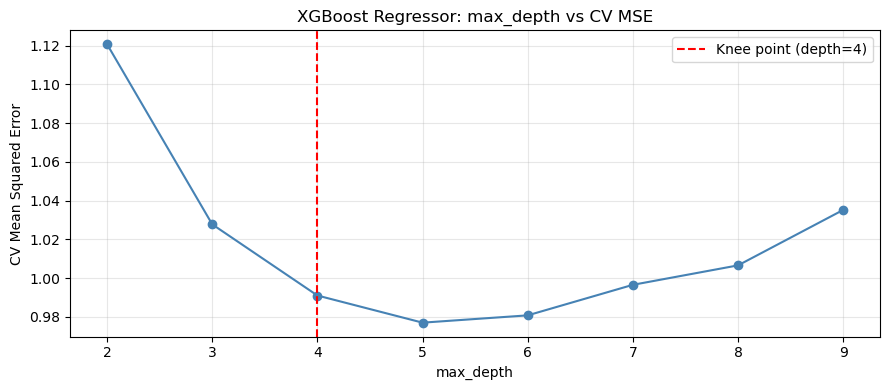

Best max_depth (knee point): 4  (CV MSE = 0.9910)


In [89]:
depths = range(2, 10)
cv_scores = []

# Evaluate performance for each depth
for d in depths:
    m = xgb.XGBRegressor(max_depth=d, n_estimators=100,
                           learning_rate=0.05, random_state=42,
                           verbosity=0, n_jobs=-1)
    scores = cross_val_score(m, X_train_aug, y_error_train, cv=3,
                             scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # convert to positive RMSE-like value

# Find knee point: The first depth where marginal gain drops below threshold
threshold = 0.02  # less than 2% improvement = diminishing returns 
best_depth = list(depths)[0]
for i in range(1, len(cv_scores)):
    if cv_scores[i - 1] - cv_scores[i] < threshold:
        best_depth = list(depths)[i - 1]
        break
else:
    best_depth = list(depths)[np.argmin(cv_scores)] # argmin since lower MSE = better performance

plt.figure(figsize=(9, 4))
plt.plot(depths, cv_scores, marker='o', color='steelblue')
plt.axvline(x=best_depth, color='red', linestyle='--', label=f'Knee point (depth={best_depth})')
plt.xlabel('max_depth')
plt.ylabel('CV Mean Squared Error')
plt.title('XGBoost Regressor: max_depth vs CV MSE')
plt.xticks(depths)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best max_depth (knee point): {best_depth}  (CV MSE = {cv_scores[list(depths).index(best_depth)]:.4f})")

#### Train XGBoost Regressor
We retrain the final model on the full training set using **149 trees** and **`max_depth = 6`** from the empirical testing earlier, then confirm consistent performance with 5-fold cross-validation. Using the same regularisation hyperparameters across early stopping, depth selection, and final training ensures `best_iteration` reflects the actual final model configuration.

<u>**Results**</u>  
**CV RMSE: 0.9781** and the low standard deviation (**±0.0201m**) confirms the model performs consistently across all 5 folds, not just getting lucky on one particular data split.

In [90]:
xgb_reg_cv = xgb.XGBRegressor(
    n_estimators      = best_iter,
    learning_rate     = 0.05,
    max_depth         = best_depth,
    min_child_weight  = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    colsample_bylevel = 0.8,
    reg_lambda        = 1.5,
    reg_alpha         = 0.05,
    random_state      = 42,
    eval_metric       = 'rmse',
    verbosity         = 0,
    n_jobs            = -1,
)

cv_rmse = np.sqrt(-cross_val_score(
    xgb_reg_cv, X_train_aug, y_error_train,
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1
))
print(f"CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} m")

CV RMSE: 0.9781 ± 0.0201 m


#### Check for under/overfitting
We compare train and test RMSE to verify the model generalises to unseen data. A large gap means the model memorised training data rather than learned real patterns.

<u>**Results**</u>  
The train-test gap is only **0.1086m**, assessed as **HEALTHY**. The small gap confirms the model has learned genuine signal patterns rather than memorising training data. 

In [91]:
# Check for underfit/overfit
xgb_reg_cv.fit(X_train_final, y_error_train)

train_preds = xgb_reg_cv.predict(X_train_final)
test_preds  = xgb_reg_cv.predict(X_test_final)

train_rmse = np.sqrt(mean_squared_error(y_error_train, train_preds))
test_rmse  = np.sqrt(mean_squared_error(y_error_test,  test_preds))
mae_error  = mean_absolute_error(y_error_test, test_preds)
r2_error   = r2_score(y_error_test, test_preds)
gap        = train_rmse - test_rmse

print("\n" + "-" * 45)
print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print("-" * 45)
print(f"{'RMSE (m)':<20} {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"{'Gap (train-test)':<20} {gap:>10.4f}")
print("-" * 45)
print(f"Error RMSE: {test_rmse:.3f}m | MAE: {mae_error:.3f}m | R²: {r2_error:.3f}")
print("-" * 45)

if train_rmse > test_rmse * 1.5:
    print("UNDERFITTING – relax regularisation")
elif gap > train_rmse * 0.3:
    print("OVERFITTING – increase regularisation or reduce depth")
else:
    print("HEALTHY – good generalisation")


---------------------------------------------
Metric                    Train       Test
---------------------------------------------
RMSE (m)                 0.8735     0.9821
Gap (train-test)        -0.1086
---------------------------------------------
Error RMSE: 0.982m | MAE: 0.451m | R²: 0.437
---------------------------------------------
HEALTHY – good generalisation


## PERFORMANCE EVALUATION
We produce a four-panel evaluation dashboard: 
* Actual vs Predicted error
* Residuals distribution
* Top 15 feature importances
* LOS vs NLOS error breakdown.

<u>**Results**</u>  
* The model predicts ranging error with **RMSE: 1.010m, MAE: 0.450m, R²: 0.405**. Predictions are nearly unbiased, with residual mean of only **+0.020m** and most errors within 1m of the true error. 
  
* The scatter plot shows good fit at typical ranges (0–4m of actual error) but underestimates large NLOS errors above 6m, where training samples are sparse.
  
* LOS corrections are highly accurate (**RMSE: 0.276m, MAE: 0.232m**); NLOS corrections are harder due to their larger, more variable ranging bias (**RMSE: 1.429m, MAE: 0.686m**). This gap is expected given the nature of NLOS signal distortion by reflections and obstacles, making their errors less predictable than LOS signals.
  
* The high-confidence LOS sanity check (**3,650 samples** where NLOS probability < 0.3) produces an RMSE of **0.276m and MAE of 0.232m**, consistent with full LOS performance, confirming the regressor handles the clearest, most reliable signals accurately.
  
* **`FRAME_LEN`** and **`MAX_NOISE`** are the two most important features, with **`nlos_pred`** (the classifier's NLOS probability, highlighted in orange) ranking 5th, confirming that feeding classifier confidence into the regressor adds genuine predictive value. Notably, **`CIR_kurtosis`** and **`PCA_2`** also rank highly, suggesting the shape and principal components of the channel impulse response carry useful error correction information.

In [92]:
# Two Stage LOS Error Correction
# Reuse existing classifier to predict LOS/NLOS
xgb_reg_cv.fit(X_train_aug, y_error_train)

# Predict how far off raw UWB distance reading is so it can be corrected
y_class_pred  = xgb_clf.predict(X_test_final)
y_class_proba = xgb_clf.predict_proba(X_test_final)[:, 1]

# Regression
y_error_pred = xgb_reg_cv.predict(X_test_aug)

# High-confidence LOS: predicted LOS AND low NLOS probability
los_mask = (y_class_pred == 0) & (y_class_proba < 0.3)
print(f"High-confidence LOS samples: {los_mask.sum()}")

if los_mask.sum() > 50:
    los_rmse = root_mean_squared_error(y_error_test[los_mask], y_error_pred[los_mask])
    los_mae  = mean_absolute_error(y_error_test[los_mask],     y_error_pred[los_mask])
    print(f"LOS Error RMSE : {los_rmse:.3f} m")
    print(f"LOS Error MAE  : {los_mae:.3f} m")
else:
    print("Not enough high-confidence LOS samples for subset evaluation")

High-confidence LOS samples: 3650
LOS Error RMSE : 0.276 m
LOS Error MAE  : 0.232 m


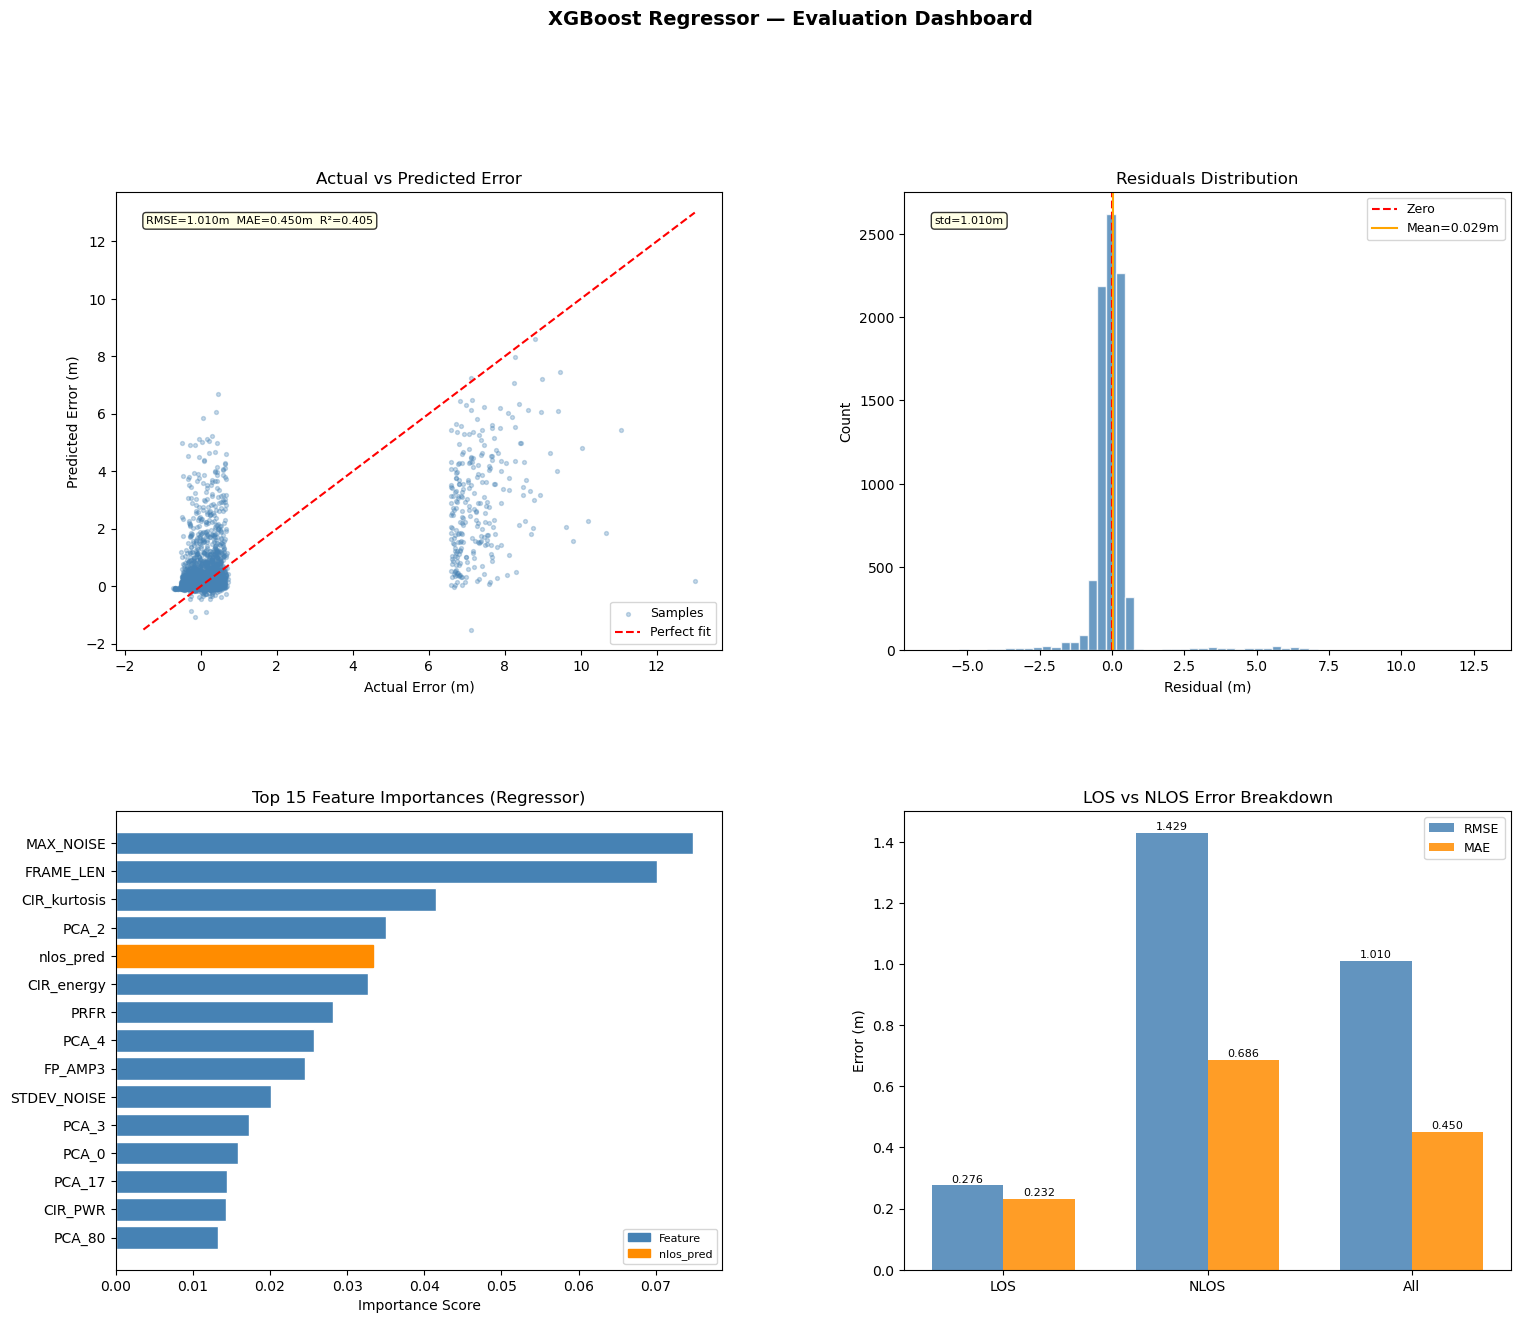

In [93]:
y_error_pred = xgb_reg_cv.predict(X_test_aug)
residuals    = y_error_test - y_error_pred

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Actual vs Predicted
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_error_test, y_error_pred, alpha=0.3, s=8, color='steelblue', label='Samples')
lims = [min(y_error_test.min(), y_error_pred.min()),
        max(y_error_test.max(), y_error_pred.max())]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
ax1.set_xlabel('Actual Error (m)')
ax1.set_ylabel('Predicted Error (m)')
ax1.set_title('Actual vs Predicted Error')
ax1.legend(fontsize=9)

rmse = np.sqrt(mean_squared_error(y_error_test, y_error_pred))
mae  = mean_absolute_error(y_error_test, y_error_pred)
r2   = r2_score(y_error_test, y_error_pred)
ax1.text(0.05, 0.93, f'RMSE={rmse:.3f}m  MAE={mae:.3f}m  R²={r2:.3f}',
         transform=ax1.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Residuals Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0,               color='red',    lw=1.5, linestyle='--', label='Zero')
ax2.axvline(residuals.mean(), color='orange', lw=1.5, linestyle='-',  label=f'Mean={residuals.mean():.3f}m')
ax2.set_xlabel('Residual (m)')
ax2.set_ylabel('Count')
ax2.set_title('Residuals Distribution')
ax2.legend(fontsize=9)
ax2.text(0.05, 0.93, f'std={residuals.std():.3f}m',
         transform=ax2.transAxes, fontsize=8,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Feature Importance (Top 15)
ax3 = fig.add_subplot(gs[1, 0])

NLOS_COL = 'nlos_pred'
feat_names = list(all_feat_names[:X_train_final.shape[1]]) + [NLOS_COL]  # safe rebuild
importance = xgb_reg_cv.feature_importances_
nlos_name  = feat_names[-1]   # always the appended column, regardless of exact string

top_n      = 15
top_idx    = np.argsort(importance)[-top_n:]
top_names  = [feat_names[i] for i in top_idx]
top_scores = importance[top_idx]

bars = ax3.barh(top_names, top_scores, color='steelblue', edgecolor='white')
for bar, name in zip(bars, top_names):
    if name == nlos_name:
        bar.set_color('darkorange')
ax3.set_xlabel('Importance Score')
ax3.set_title(f'Top {top_n} Feature Importances (Regressor)')
ax3.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue',  label='Feature'),
    plt.Rectangle((0,0),1,1, color='darkorange', label=nlos_name),
], fontsize=8)

# LOS vs NLOS Error Breakdown
ax4 = fig.add_subplot(gs[1, 1])

los_mask_test  = (y_class_pred == 0)
nlos_mask_test = (y_class_pred == 1)

breakdown = {
    'LOS':  {'RMSE': np.sqrt(mean_squared_error(y_error_test[los_mask_test],  y_error_pred[los_mask_test])),
              'MAE':  mean_absolute_error(y_error_test[los_mask_test],  y_error_pred[los_mask_test])},
    'NLOS': {'RMSE': np.sqrt(mean_squared_error(y_error_test[nlos_mask_test], y_error_pred[nlos_mask_test])),
              'MAE':  mean_absolute_error(y_error_test[nlos_mask_test], y_error_pred[nlos_mask_test])},
    'All':  {'RMSE': rmse, 'MAE': mae},
}

x      = np.arange(3)
labels = list(breakdown.keys())
rmses  = [breakdown[k]['RMSE'] for k in labels]
maes   = [breakdown[k]['MAE']  for k in labels]
width  = 0.35

ax4.bar(x - width/2, rmses, width, label='RMSE', color='steelblue',  alpha=0.85)
ax4.bar(x + width/2, maes,  width, label='MAE',  color='darkorange', alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_ylabel('Error (m)')
ax4.set_title('LOS vs NLOS Error Breakdown')
ax4.legend(fontsize=9)
for i, (r, m) in enumerate(zip(rmses, maes)):
    ax4.text(i - width/2, r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax4.text(i + width/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=8)

plt.suptitle('XGBoost Regressor — Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.show()

## SUMMARY REPORT
A summary of all key metrics for the tuned XGBoost regression model.

<u>**Results**</u>  
The model corrects UWB ranging error with sub-metre accuracy on average. LOS corrections are highly accurate while NLOS corrections are less accurate due to larger signal distortion but remain useful. The near-zero residual mean confirms the model does not systematically over- or under-correct in one direction.

In [94]:
mae_error = mean_absolute_error(y_error_test, y_error_pred)
r2_error  = r2_score(y_error_test, y_error_pred)
test_rmse = rmse   # alias from evaluation cell

print("=" * 50)
print("       FINAL REGRESSOR SUMMARY")
print("=" * 50)
print(f"Model              : XGBoost Error Regressor")
print(f"Trees used         : {xgb_reg.best_iteration} / 1000")
print(f"LOS median (proxy) : {global_fallback:.3f} m")
print("-" * 55)
print(f"CV RMSE            : {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} m")
print(f"Train RMSE         : {train_rmse:.4f} m")
print(f"Test  RMSE         : {test_rmse:.4f} m")
print(f"Generalisation gap : {gap:.4f} m  ({'HEALTHY' if abs(gap) < train_rmse * 0.3 else 'CHECK OVERFIT'})")
print(f"Test  MAE          : {mae_error:.4f} m")
print(f"Test  R²           : {r2_error:.4f}")
print("-" * 55)
print(f"LOS  RMSE          : {breakdown['LOS']['RMSE']:.4f} m  |  MAE: {breakdown['LOS']['MAE']:.4f} m")
print(f"NLOS RMSE          : {breakdown['NLOS']['RMSE']:.4f} m  |  MAE: {breakdown['NLOS']['MAE']:.4f} m")
print("=" * 50)

       FINAL REGRESSOR SUMMARY
Model              : XGBoost Error Regressor
Trees used         : 149 / 1000
LOS median (proxy) : 2.430 m
-------------------------------------------------------
CV RMSE            : 0.9781 ± 0.0201 m
Train RMSE         : 0.8735 m
Test  RMSE         : 1.0100 m
Generalisation gap : -0.1086 m  (HEALTHY)
Test  MAE          : 0.4501 m
Test  R²           : 0.4048
-------------------------------------------------------
LOS  RMSE          : 0.2758 m  |  MAE: 0.2320 m
NLOS RMSE          : 1.4291 m  |  MAE: 0.6864 m


## INTEGRATED 3 STAGE TEST
---
Having trained both the classifier and the error correction regressor, in this section we combine them into a single end-to-end pipeline and test it on real samples.  
  
The three stages are:
1. **Classify**: Determine if each signal is LOS or NLOS
   
2. **Correct**: If LOS, subtract the predicted ranging error from the raw measurement
   
3. **Second Path**: Extract a secondary CIR peak to estimate an alternative range for NLOS-heavy environments

### STAGE 1 & 2: CLASSIFY & CORRECT PIPELINE
We run 10 test samples through the full two-stage pipeline to demonstrate how the classifier and regressor work in tandem on individual measurements.
  
For each sample:
* **Stage 1**: The classifier predicts LOS or NLOS and outputs a confidence score (NLOS probability)
  
* **Stage 2**: If predicted LOS, the regressor predicts how far off the raw range reading is and subtracts it to produce a corrected range. If predicted NLOS, the sample is discarded as unreliable
  
The corrected range is computed as `raw_range - predicted_error`

<div style="background:#f0f0f0; border-left:4px solid #999; padding:10px; border-radius:3px;">
<strong>Note:</strong> The raw range used here is the <strong>unscaled physical range in metres</strong> from <i>X_summary_test</i>, not the scaled version from <i>X_test_final</i>. Using the scaled version would apply corrections in standard-deviation units rather than metres, producing physically meaningless results.
</div>

<br>
  
<u>**Results**</u>  
The pipeline correctly discarded all 5 true NLOS samples and corrected 4 out of 5 true LOS samples; **Sample 2** was incorrectly classified as NLOS (P(NLOS)=0.812), representing a false positive discard. This is consistent with the classifier's recall of ~88%, where some borderline LOS samples near obstructions are misclassified.

The scatter plot shows all 4 corrected points fall **below the no-correction diagonal**, confirming the regressor successfully reduced the raw range readings. The corrections range from \~0.05m to \~0.5m, consistent with typical LOS ranging bias.

=== TWO-STAGE UWB LOCALIZATION PIPELINE ===
Input → Classify → [LOS: Correct range] or [NLOS: Discard]

Demo: 10 Test Measurements
Sample 1: True=LOS   P(NLOS)=0.088  → CORRECTED: 3.089m
Sample 2: True=LOS   P(NLOS)=0.812  → DISCARD (NLOS)
Sample 3: True=LOS   P(NLOS)=0.362  → CORRECTED: 2.990m
Sample 4: True=NLOS  P(NLOS)=0.995  → DISCARD (NLOS)
Sample 5: True=NLOS  P(NLOS)=0.887  → DISCARD (NLOS)
Sample 6: True=LOS   P(NLOS)=0.010  → CORRECTED: 2.525m
Sample 7: True=NLOS  P(NLOS)=0.939  → DISCARD (NLOS)
Sample 8: True=NLOS  P(NLOS)=0.833  → DISCARD (NLOS)
Sample 9: True=NLOS  P(NLOS)=0.997  → DISCARD (NLOS)
Sample 10: True=LOS   P(NLOS)=0.006  → CORRECTED: 3.644m

=== PIPELINE SUMMARY TABLE ===
 Sample True NLOS  NLOS Prob True Range          Decision  Corrected Range (m)
      1       LOS      0.088     3.040m CORRECTED: 3.089m             3.089401
      2       LOS      0.812     4.170m    DISCARD (NLOS)                  NaN
      3       LOS      0.362     3.000m CORRECTED: 2.990m

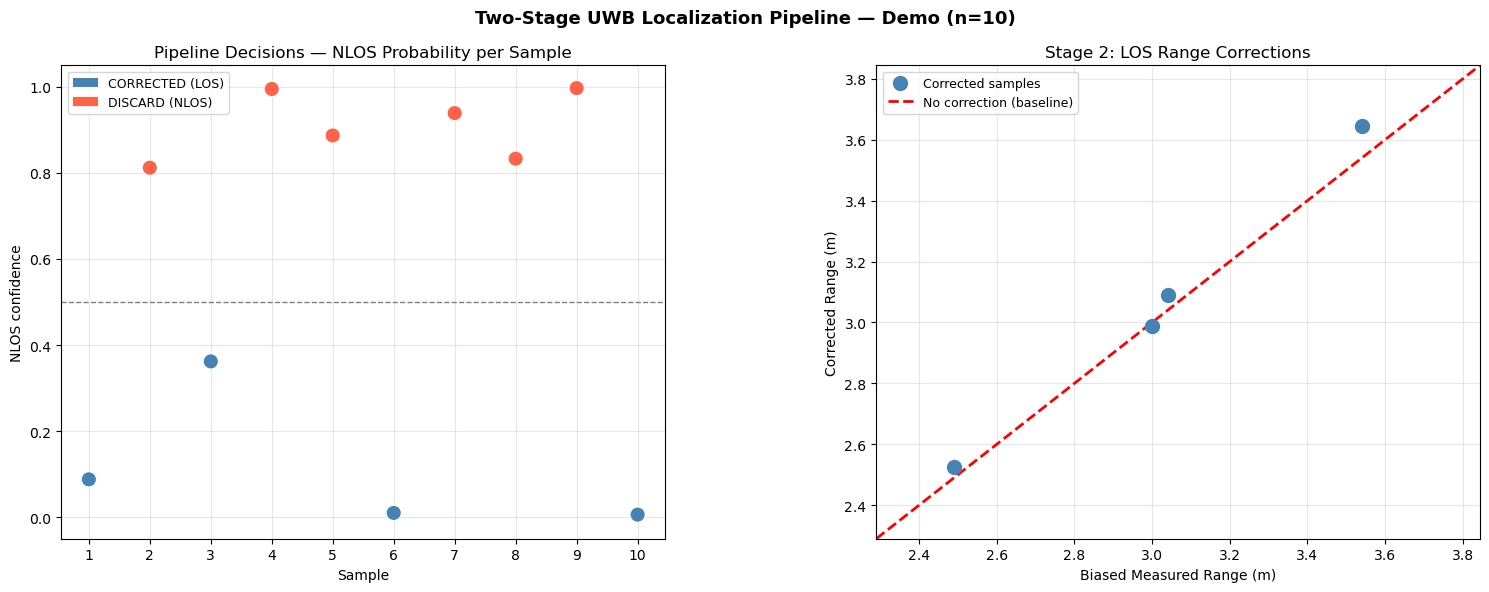

In [95]:
print("=== TWO-STAGE UWB LOCALIZATION PIPELINE ===")
print("Input → Classify → [LOS: Correct range] or [NLOS: Discard]\n")

# Simulate 10 new measurements (your test set slice)
n_demo         = 10
test_slice     = X_test_final[:n_demo]
test_slice_aug = X_test_aug[:n_demo]
true_nlos      = y_test[:n_demo]
true_range     = X_summary_test[:, 0][:n_demo] #not the scaled version from X_test_final) because you're computing a physically meaningful corrected 
# range in metres — corrected_range = true_range[i] - error_pred. If you accidentally used the scaled version, your corrections would be in standard-deviation units, not metres.

print("Demo: 10 Test Measurements")
results = []

for i in range(n_demo):
    # Stage 1: CLASSIFICATION
    class_pred  = xgb_clf.predict(test_slice[i:i+1])[0]
    class_proba = xgb_clf.predict_proba(test_slice[i:i+1])[0, 1]
    
    if class_pred == 1: # NLOS or low confidence
        decision = "DISCARD (NLOS)"
        corrected_range = None
    # LOS - Stage 2 REGRESSION
    else:  
        error_pred = xgb_reg_cv.predict(test_slice_aug[i:i+1])[0]
        corrected_range = true_range[i] - error_pred  # measured - predicted_error
        decision = f"CORRECTED: {corrected_range:.3f}m"
    
    results.append({
        'Sample': i+1,
        'True NLOS': 'NLOS' if true_nlos[i] else 'LOS', 
        'NLOS Prob': round(class_proba, 3), 
        'True Range': f"{true_range[i]:.3f}m",
        'Decision': decision,
        'Corrected Range (m)': corrected_range if class_pred == 0 else None
    })
    
    print(f"Sample {i+1}: True={'NLOS' if true_nlos[i] else 'LOS':4s}  "
          f"P(NLOS)={class_proba:.3f}  → {decision}")

# Summary table
results_df = pd.DataFrame(results)
print("\n=== PIPELINE SUMMARY TABLE ===")
print(results_df.to_string(index=False))

# Pipeline performance stats
los_corrected_mask = (true_nlos == 0)  # True LOS samples
n_corrected = sum((true_nlos == 0) & (np.array([r['Decision']!='DISCARD (NLOS)' for r in results])))
if los_corrected_mask.sum() > 0:
    print(f"\nCorrected {n_corrected}/{los_corrected_mask.sum()} true LOS samples "
          f"({100 * n_corrected / los_corrected_mask.sum():.0f}%)")

# Visualization: Pipeline decisions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Strip plot: NLOS probability per sample, coloured by decision
colors = ['steelblue' if 'CORRECTED' in r['Decision'] else 'tomato' for r in results]
ax1.scatter(results_df['Sample'], 
            [r['NLOS Prob'] for r in results],
            c=colors, s=120, zorder=3, edgecolors='white', linewidths=0.8)
ax1.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary (0.5)')
ax1.set_xlabel('Sample')
ax1.set_ylabel('NLOS confidence')
ax1.set_title('Pipeline Decisions — NLOS Probability per Sample')
ax1.set_xticks(results_df['Sample'])
ax1.set_ylim(-0.05, 1.05)
ax1.legend(handles=[
    Patch(facecolor='steelblue', label='CORRECTED (LOS)'),
    Patch(facecolor='tomato',    label='DISCARD (NLOS)'),
], fontsize=9)
ax1.grid(alpha=0.3)

# Corrected vs True range
los_indices = [i for i, r in enumerate(results) if r['Corrected Range (m)'] is not None]
if los_indices:
    true_los = [true_range[i] for i in los_indices]
    corr_los  = [results[i]['Corrected Range (m)'] for i in los_indices]
    lims = [min(true_los + corr_los) - 0.2, max(true_los + corr_los) + 0.2]
    ax2.scatter(true_los, corr_los, color='steelblue', s=100, zorder=3, label='Corrected samples')
    ax2.set_xlim(lims)
    ax2.set_ylim(lims)
    ax2.set_xlabel('Biased Measured Range (m)')
    ax2.set_ylabel('Corrected Range (m)')
    ax2.plot(lims, lims, 'r--', lw=2, label='No correction (baseline)')
    ax2.set_title('Stage 2: LOS Range Corrections')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No LOS samples in demo slice',
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Stage 2: LOS Range Corrections')

plt.suptitle('Two-Stage UWB Localization Pipeline — Demo (n=10)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)
plt.show()

### STAGE 3: FIND SECOND DOMINANT CIR PATH
NLOS signals travel via reflected paths, arriving at the receiver later than a direct LOS signal would. The **Channel Impulse Response (CIR)** captures the full signal over time, meaning peaks appearing after the first detected path represent signals that travelled longer, reflected routes.

We scan the CIR for a second dominant peak to estimate an alternative path range:
1. **Suppress** the region around the first path index (±10 samples) to prevent re-detecting the same peak
   
2. **Search** only after the first path (at least 10 samples ahead) as earlier arrivals are physically impossible reflections
   
3. **Noise threshold** that only accept peaks above 3× the noise floor (`STDEV_NOISE`) to ignore noise spikes
   
4. **Convert** the index difference to distance using UWB's ~0.3m/ns resolution:  
   `range2 = range1 + (fp2_index − fp1_index) × 0.3`

The CIR visualisation (3 samples) shows the first path index (red dashed) and the suppression window end (orange dotted), illustrating where the second peak search begins for both LOS and NLOS samples.

<u>**Results**</u>  
Every second path index (`FP_IDX2`) is consistently **10–19 samples after** `FP_IDX`, and the second range is always larger than the first; both physically expected for a reflected signal travelling a longer route.

The mean extra distance of **4.044m** represents the average additional path length of the reflected signal. This large separation confirms that second peaks are genuine multipath components, not noise, making them useful as supplementary range estimates or as features indicating severe NLOS environments.

The CIR plots confirm this visually:  
* **LOS samples (0, 100)**: Show a sharp rise at the first path index, with a dominant energy cluster immediately after, followed by a rapidly decaying tail with minor secondary peaks.
  
* **NLOS samples (500)**: Show a flatter, more spread response with a visible secondary peak of comparable amplitude (characteristic of a signal that has bounced off a surface before reaching the receiver).

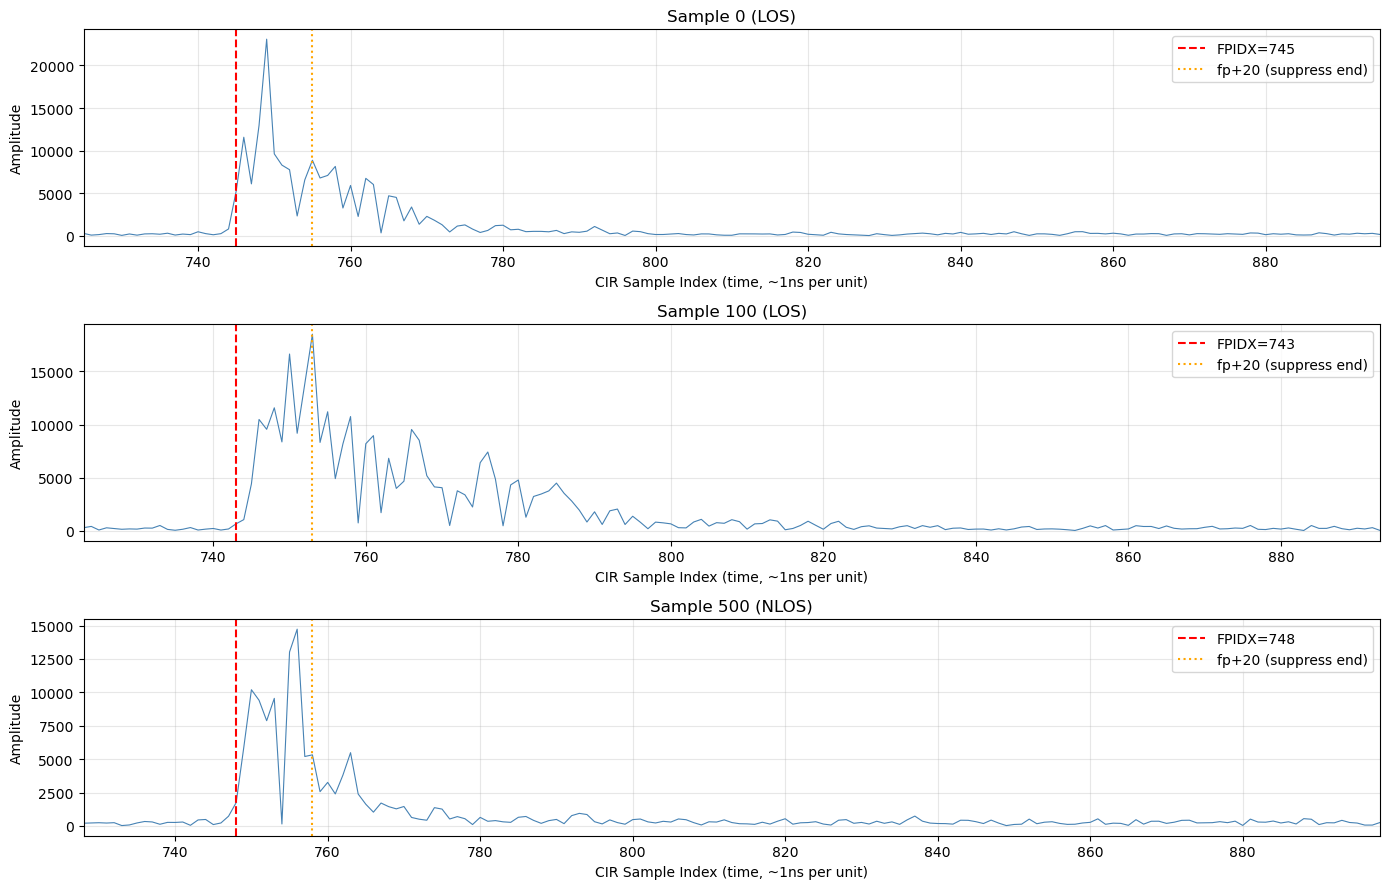

In [96]:
# CIR plot
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
sample_ids = [0, 100, 500]  # pick LOS + NLOS samples

for ax, idx in zip(axes, sample_ids):
    cir = X_cir.values[idx].astype(float)
    fp  = int(X_summary['FP_IDX'].values[idx])
    label = 'LOS' if y.values[idx] == 0 else 'NLOS'

    ax.plot(cir, color='steelblue', linewidth=0.8)
    ax.axvline(fp, color='red', linestyle='--', label=f'FPIDX={fp}')
    ax.axvline(fp + 10, color='orange', linestyle=':', label='fp+20 (suppress end)')
    ax.set_xlim(fp - 20, fp + 150)
    ax.set_title(f'Sample {idx} ({label})')
    ax.set_xlabel('CIR Sample Index (time, ~1ns per unit)') 
    ax.set_ylabel('Amplitude')                               
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()

In [97]:
# Use existing preprocessing variables instead of df
cir_array   = X_cir.values                          # shape (42000, 1016)
fpidx_vals  = X_summary['FP_IDX'].values.astype(int) # first path index
range1_vals = X_summary['RANGE'].values             # measured range for path 1

SUPPRESS_WINDOW = 10   # blank out ±10 samples around first peak
SEARCH_AFTER    = 10   # start looking at least 10 samples after first peak

second_fpidx = []
second_range = []
second_label = []  # always NLOS = 1

for i in range(len(X_summary)):
    cir = cir_array[i].copy().astype(float)
    fp  = fpidx_vals[i]

    # Suppress region around first peak
    lo = max(0, fp - SUPPRESS_WINDOW)
    hi = min(len(cir), fp + SUPPRESS_WINDOW)
    cir[lo:hi] = 0

    # Only search AFTER the first path
    search_start = min(fp + SEARCH_AFTER, len(cir) - 1)
    cir[:search_start] = 0

    # Find peaks in remaining CIR
    noise_floor = float(X_summary['STDEV_NOISE'].values[i]) * 3
    peaks, _ = find_peaks(cir, height=noise_floor)

    fp2 = peaks[np.argmax(cir[peaks])] if len(peaks) > 0 else fp + SUPPRESS_WINDOW + 1

    # Convert index difference to distance (1 ns resolution, ~0.3 m/ns)
    range2 = range1_vals[i] + (fp2 - fp) * 0.3

    second_fpidx.append(fp2)
    second_range.append(range2)
    second_label.append(1)  # always NLOS

# Store results in a new summary DataFrame
path2_df = X_summary[['FP_IDX', 'RANGE']].copy().reset_index(drop=True)
path2_df['FP_IDX2'] = second_fpidx
path2_df['RANGE2'] = second_range
path2_df['NLOS2']  = second_label

print(path2_df.head(10))
print(f"\nMean Path-2 range:              {path2_df['RANGE2'].mean():.3f} m")
print(f"Mean extra distance (P2 - P1):  {(path2_df['RANGE2'] - path2_df['RANGE']).mean():.3f} m")

   FP_IDX  RANGE  FP_IDX2  RANGE2  NLOS2
0   745.0   3.90      755    6.90      1
1   749.0   0.66      759    3.66      1
2   746.0   7.86      763   12.96      1
3   750.0   3.48      765    7.98      1
4   746.0   1.19      757    4.49      1
5   746.0   1.27      760    5.47      1
6   748.0   0.28      765    5.38      1
7   744.0   1.23      754    4.23      1
8   745.0   4.99      762   10.09      1
9   749.0   1.17      761    4.77      1

Mean Path-2 range:              7.876 m
Mean extra distance (P2 - P1):  4.044 m
